# Capstone Project: French Railway Delays

**Overview**: In this capstone project, the key research question to be answered is - how can a railway operator improve the reliability of its railway system? Specifically, past data on a particular route (liaison) will be used to predict if the route (liaison) will require more attention (is high risk) the following month.

**Data Source**: https://www.kaggle.com/datasets/gatandubuc/public-transport-traffic-data-in-france?select=Regularities_by_liaisons_Trains_France.csv

This dataset contains all the point-to-point delay / on-time data for the France High Speed Rail network (TSV), accompanied by the causes of the delays if any. 

**Expected Results**: The analysis is expected to reveal the "what, where, when, why" factors contributing to train delays, and provide simple predictive tools to forecast and mitigate future disruptions through identification of future high risk routes. 

**Why it matters**: Public transport commutes affects millions of people daily and can be disruptive when then system is not reliable. Doing a detailed analysis of the reasons for potential faults can advise the railway operator to pre-emptively take interventions either in terms of operations (e.g. on rainy days, have additional surveillance), or maintenance (e.g. check trains more thoroughly after a rainy day), ultimately improving the reliability of the system that serves so many on a daily basis. 



## A. Business Understanding

##### _Step 1: Import Relevant Libraries_

In [1]:
# Import Libraries
# The basics 
import numpy as np
import pandas as pd 

# Importing  tools for visualization
import seaborn as sns
import plotly.express as px 
import matplotlib.pyplot as plt

# Import tools for data preprocessing and pipelines 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector, SelectFromModel 

# Import tools for model creation 
from sklearn.linear_model import LinearRegression,Lasso,Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Import evaluation metric libraries
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.metrics import recall_score, f1_score, average_precision_score
from sklearn.metrics import precision_recall_curve, make_scorer


# Import model selection libraries
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

##### _Step 2: Load the Data and Take a Look_

In [2]:
df = pd.read_csv('data/traindelays.csv')
df.head()

,Year,Month,Departure station,Arrival station,Average travel time (min),Number of expected circulations,Number of cancelled trains,Number of late trains at departure,Average delay of late departing trains (min),Average delay of all departing trains (min),...,Average train delay > 15min,Number of late trains > 30min,Number of late trains > 60min,Period,Delay due to external causes,Delay due to railway infrastructure,Delay due to traffic management,Delay due to rolling stock,Delay due to station management and reuse of material,Delay due to travellers taken into account
0,2019,7.0,ANGOULEME,PARIS MONTPARNASSE,131.914980,247.0,0.0,191.0,3.576353,2.678273,...,32.965873,7.0,2.0,2019-07,25.000000,15.000000,27.500000,12.500000,2.500000,17.500000
1,2019,7.0,PARIS MONTPARNASSE,LA ROCHELLE VILLE,175.611570,242.0,0.0,178.0,9.780805,7.033609,...,32.057143,14.0,2.0,2019-07,20.000000,24.444444,26.666667,24.444444,0.000000,4.444444
2,2019,7.0,LE MANS,PARIS MONTPARNASSE,62.395349,435.0,5.0,391.0,3.896974,3.529341,...,42.367241,13.0,4.0,2019-07,16.176471,32.352941,26.470588,14.705882,2.941176,7.352941
3,2019,7.0,ST MALO,PARIS MONTPARNASSE,172.421053,114.0,0.0,101.0,1.950990,1.685673,...,27.620833,2.0,0.0,2019-07,15.384615,15.384615,23.076923,38.461538,0.000000,7.692308
4,2019,7.0,PARIS MONTPARNASSE,ST PIERRE DES CORPS,67.310000,404.0,4.0,284.0,8.379108,5.803125,...,37.658333,12.0,3.0,2019-07,18.461538,12.307692,40.000000,16.923077,7.692308,4.615385


#### _Step 3: Explore General Characteristics_ 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7806 entries, 0 to 7805
Data columns (total 32 columns):
 #   Column                                                                                                               Non-Null Count  Dtype  
---  ------                                                                                                               --------------  -----  
 0   Year                                                                                                                 7806 non-null   int64  
 1   Month                                                                                                                7806 non-null   float64
 2   Departure station                                                                                                    7806 non-null   object 
 3   Arrival station                                                                                                      7806 non-null   object 
 4   Average trav

In [4]:
#check null values 
df.isnull().sum()

Year                                                                                                                      0
Month                                                                                                                     0
Departure station                                                                                                         0
Arrival station                                                                                                           0
Average travel time (min)                                                                                                63
Number of expected circulations                                                                                          63
Number of cancelled trains                                                                                                0
Number of late trains at departure                                                                                        0
Average 

#### _Step 4: Handle NULL Values_

In [5]:
# Remove columns with too many null values
df = df.drop(columns=['Comment (optional) delays at departure', 'Comment (optional) delays on arrival'])

In [6]:
# drop duplicate columns
df = df.drop(columns=["% trains late due to external causes (weather, obstacles, suspicious packages, malevolence, social movements, etc.)",
"% trains late due to railway infrastructure (maintenance, works)",
"% trains late due to traffic management (rail line traffic, network interactions)",
"% trains late due to rolling stock",
"% trains late due to station management and reuse of material",
"% trains late due to passenger traffic (affluence, PSH management, connections)"]) 

In [7]:
# drop rows where having a null value doesnt make sense - route may no longer be in operations
df = df.dropna(subset=["Average travel time (min)", "Number of expected circulations"])

In [8]:
# impute rows where having a null value makes sense - e.g. when #trains late is zero 
cols = ["Number of trains late on arrival", "Average delay of late arriving trains (min)", "Average train delay > 15min", "Number of late trains > 30min", "Number of late trains > 60min", "Number of late trains > 15min"]
df[cols] = df[cols].fillna(0)

In [9]:
# investigate rows for which delay due to some reason is NULL 
df[df["Delay due to external causes"].isna()]
# create a new column to indicate delay cause due to "others" / maybe there were no delays 
df['Delay due to others'] = df['Delay due to external causes'].isna().astype(int) * 100
# fill the rest of the null values with 0
df = df.fillna(0)

In [10]:
# drop rows that are less meaningful for our analysis 
# presume trains late at departure are less crucial so long as it arrived on time 
df = df.drop(columns=["Number of late trains at departure", "Average delay of late departing trains (min)", "Average delay of all departing trains (min)"])

#### _Step 5: Do Some Feature Engineering_

Create some new meaningful columns before proceeding with analysis

In [11]:
# create a liaison column for route-based analysis
df['liaison'] = df['Departure station'].astype(str) + ' - ' + df['Arrival station'].astype(str)


In [12]:
# create new features to normalise useful KPIs
df['cancellation_rate'] = df['Number of cancelled trains'] / df['Number of expected circulations']
df['lateness_rate'] = df['Number of trains late on arrival'] / df['Number of expected circulations']


In [13]:
# make sure Period is true date-time
# we retain year and month as it may be useful later
df['period'] = pd.to_datetime(df['Period'], format='%Y-%m')
# drop the Period column 
df = df.drop(columns='Period')


In [14]:
# Rename columns for easier access 
df = df.rename(columns={
    'Year': 'year',
    'Month': 'month',
    'Departure station': 'departure_station',
    'Arrival station': 'arrival_station',
    'Number of expected circulations': 'expected_trains',
    'Number of cancelled trains': 'cancelled_trains',
    'Number of trains late on arrival': 'late_trains',
    'Average travel time (min)': 'avg_travel_time',
    'Average delay of late arriving trains (min)': 'avg_delay_all_late_trains',
    'Average delay of all arriving trains (min)': 'avg_delay_all_trains',
    'Average train delay > 15min': 'avg_delay_over_15min',
    'Number of late trains > 15min': 'late_trains_over_15min',
    'Number of late trains > 30min': 'late_trains_over_30min',
    'Number of late trains > 60min': 'late_trains_over_60min',
    'Delay due to external causes': 'cause_ext',
    'Delay due to railway infrastructure': 'cause_infra',
    'Delay due to traffic management': 'cause_traffic',
    'Delay due to rolling stock': 'cause_rs',
    'Delay due to station management and reuse of material': 'cause_station',
    'Delay due to travellers taken into account': 'cause_pax',
    'Delay due to others': 'cause_others',
})

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7743 entries, 0 to 7805
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   year                       7743 non-null   int64         
 1   month                      7743 non-null   float64       
 2   departure_station          7743 non-null   object        
 3   arrival_station            7743 non-null   object        
 4   avg_travel_time            7743 non-null   float64       
 5   expected_trains            7743 non-null   float64       
 6   cancelled_trains           7743 non-null   float64       
 7   late_trains                7743 non-null   float64       
 8   avg_delay_all_late_trains  7743 non-null   float64       
 9   avg_delay_all_trains       7743 non-null   float64       
 10  late_trains_over_15min     7743 non-null   float64       
 11  avg_delay_over_15min       7743 non-null   float64       
 12  late_trains

#### _Step 6: Univariate Analysis_

In [16]:
# take a look at the numerical features
df.describe()

,year,month,avg_travel_time,expected_trains,cancelled_trains,late_trains,avg_delay_all_late_trains,avg_delay_all_trains,late_trains_over_15min,avg_delay_over_15min,...,cause_ext,cause_infra,cause_traffic,cause_rs,cause_station,cause_pax,cause_others,cancellation_rate,lateness_rate,period
count,7743.000000,7743.000000,7743.000000,7743.000000,7743.000000,7743.000000,7743.000000,7743.000000,7743.000000,7743.000000,...,7743.000000,7743.000000,7743.000000,7743.000000,7743.000000,7743.000000,7743.000000,7743.000000,7743.000000,7743
mean,2017.323518,6.232210,166.759261,266.510913,7.913212,35.847475,32.576869,5.212800,24.529381,29.212604,...,25.991075,24.819048,18.679370,17.623391,6.587000,3.545641,2.686297,0.036791,0.135702,2017-10-04 06:54:32.220069632
min,2015.000000,1.000000,35.888889,1.000000,0.000000,0.000000,-40.109259,-472.638889,0.000000,-118.022363,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015-01-01 00:00:00
25%,2016.000000,3.000000,100.643605,163.000000,0.000000,16.000000,23.689231,2.829885,10.000000,8.920039,...,14.814815,14.285714,7.894737,8.695652,0.000000,0.000000,0.000000,0.000000,0.082276,2016-06-01 00:00:00
50%,2017.000000,6.000000,162.178808,227.000000,1.000000,28.000000,30.806000,4.680056,19.000000,31.911765,...,24.137931,23.076923,16.666667,15.789474,4.878049,1.369863,0.000000,0.005415,0.122102,2017-11-01 00:00:00
75%,2019.000000,9.000000,207.885957,352.000000,6.000000,48.000000,39.068981,7.278924,33.000000,41.194327,...,35.416667,33.333333,26.666667,24.242424,9.958678,5.263158,0.000000,0.023585,0.174555,2019-02-01 00:00:00
max,2020.000000,12.000000,786.500000,960.000000,279.000000,235.000000,258.000000,83.388889,192.000000,258.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,0.926829,1.000000,2020-06-01 00:00:00
std,1.584957,3.449688,80.737092,157.456548,21.077172,29.246202,14.161564,8.397351,20.326536,19.004220,...,16.630752,16.323035,15.004109,13.425714,7.848118,5.734784,16.169332,0.086778,0.074894,NaN


In [17]:
#take a look at categorical features 
cat_columns = df.select_dtypes(exclude="number").columns

cat_columns_values = []
for col in cat_columns:
    nunique = df[col].nunique()
    unique_vals = df[col].unique()
    cat_columns_values.append({
        'column': col,
        'nunique': nunique,
        'unique_values': unique_vals
    })
cat_columns_df = pd.DataFrame(cat_columns_values)
cat_columns_df 

,column,nunique,unique_values
0,departure_station,59,"[ANGOULEME, PARIS MONTPARNASSE, LE MANS, ST MA..."
1,arrival_station,59,"[PARIS MONTPARNASSE, LA ROCHELLE VILLE, ST PIE..."
2,liaison,130,"[ANGOULEME - PARIS MONTPARNASSE, PARIS MONTPAR..."
3,period,66,"[2019-07-01 00:00:00, 2018-03-01 00:00:00, 201..."


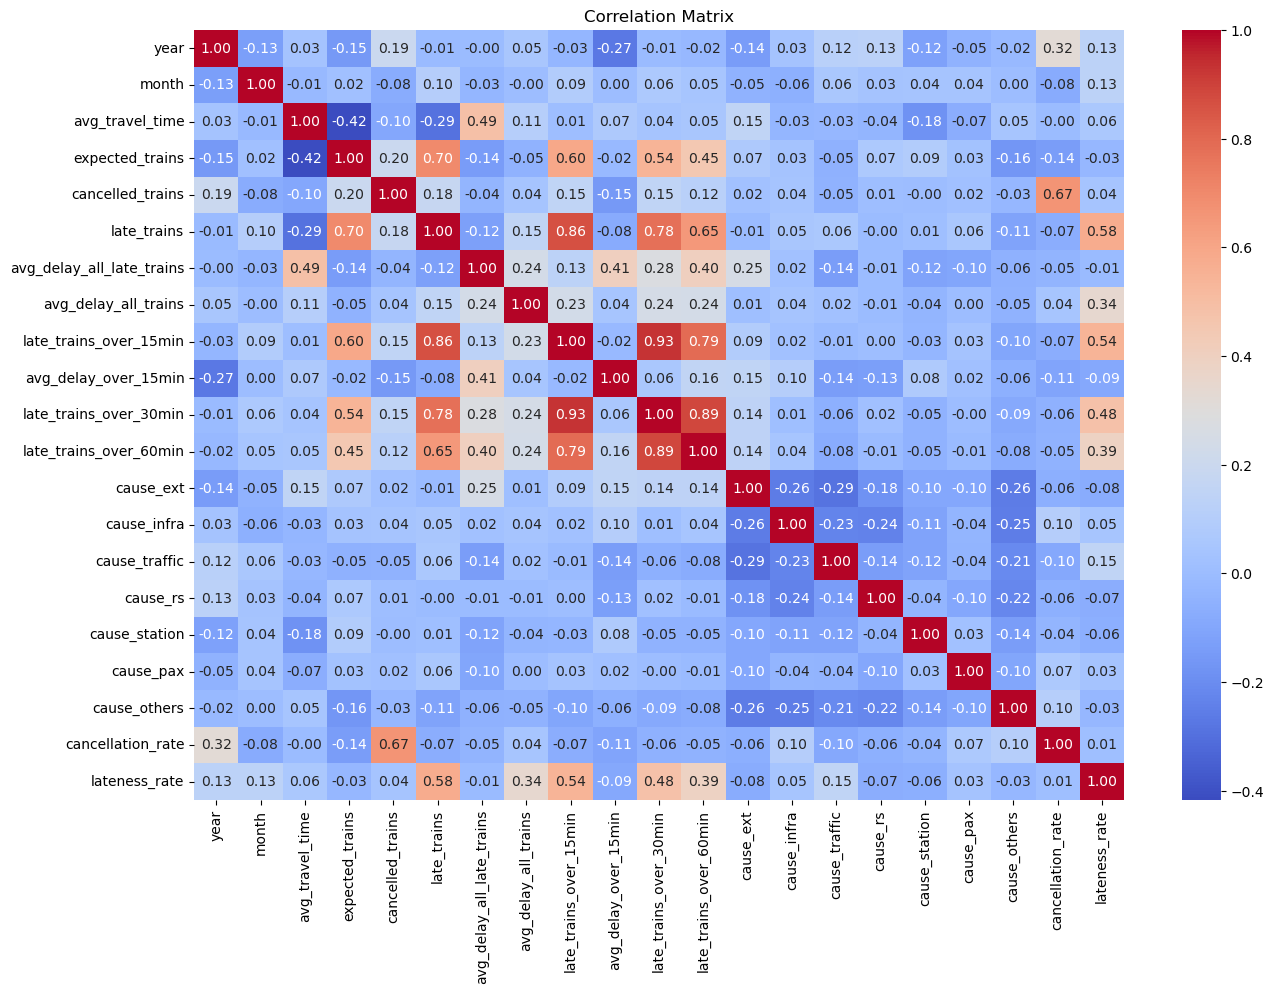

In [18]:
# Look at overall correlation matrix 
plt.figure(figsize=(15,10))
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()  

**Observation**: Looking at the `expected_trains` feature, the more trains planned for a route, the shorter its average travel time (i.e. shorter routes are more popular), and statistically, the more late trains there are, and hence the higher likelihood of trains delayed for >15 min. 

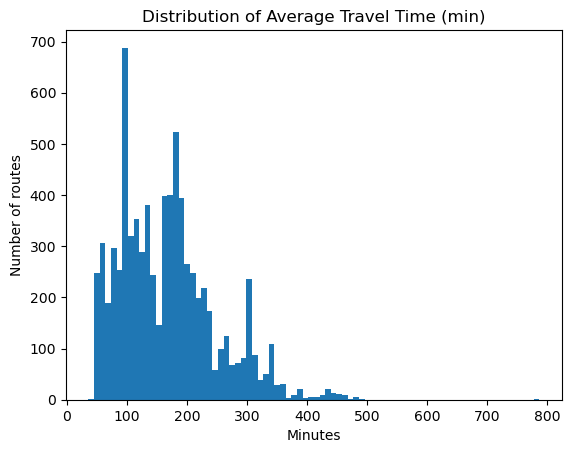

In [19]:
# take a look at the overall spread of journey types based on travel time

plt.figure()
plt.hist(df['avg_travel_time'], bins=80)
plt.title('Distribution of Average Travel Time (min)')
plt.xlabel('Minutes')
plt.ylabel('Number of routes')
plt.show()



**Observation**: One peak around the 100min mark, and another smaller peak around 180min. 

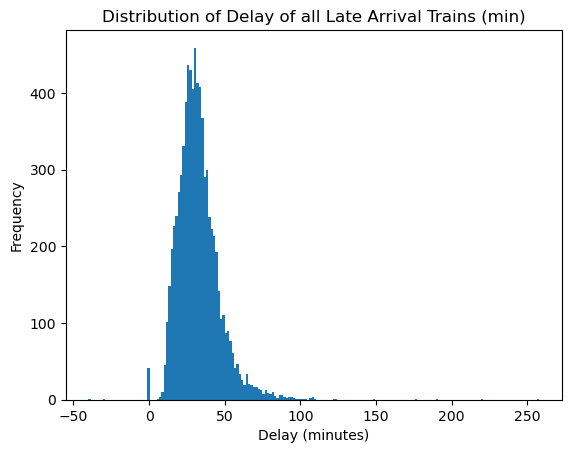

In [20]:
#Observe spread of late arriving trains  
plt.figure()
plt.hist(df["avg_delay_all_late_trains"], bins='fd')     # smarter binning
plt.title('Distribution of Delay of all Late Arrival Trains (min)')
plt.xlabel('Delay (minutes)')
plt.ylabel('Frequency')
plt.show()


**Observation**: Looks almost like a normal distribution, with the peak at around 45min, and a relatively small variance. There seems to be some negative values. 

In [21]:
#investigate outliers - delays cannot be negative
df[df['avg_delay_all_late_trains'] < 0]
# drop rows where delays are negative
df = df[df['avg_delay_all_late_trains'] >= 0]
# investigate outliers - very high impact delays
df[df['avg_delay_all_late_trains']>150]
# choose to keep these for now



,year,month,departure_station,arrival_station,avg_travel_time,expected_trains,cancelled_trains,late_trains,avg_delay_all_late_trains,avg_delay_all_trains,...,cause_infra,cause_traffic,cause_rs,cause_station,cause_pax,cause_others,liaison,cancellation_rate,lateness_rate,period
1942,2016,12.0,PARIS EST,FRANCFORT,127.275000,31.0,1.0,1.0,220.0,-93.291667,...,0.0,0.0,0.0,0.0,0.0,0,PARIS EST - FRANCFORT,0.032258,0.032258,2016-12-01
2235,2016,5.0,LA ROCHELLE VILLE,PARIS MONTPARNASSE,197.271186,59.0,0.0,1.0,176.0,3.661017,...,0.0,100.0,0.0,0.0,0.0,0,LA ROCHELLE VILLE - PARIS MONTPARNASSE,0.000000,0.016949,2016-05-01
3207,2018,3.0,MARSEILLE ST CHARLES,MADRID,464.000000,31.0,1.0,1.0,190.0,4.266667,...,0.0,0.0,0.0,0.0,0.0,100,MARSEILLE ST CHARLES - MADRID,0.032258,0.032258,2018-03-01
4604,2015,10.0,NANTES,STRASBOURG,325.088889,45.0,0.0,1.0,258.0,7.022222,...,100.0,0.0,0.0,0.0,0.0,0,NANTES - STRASBOURG,0.000000,0.022222,2015-10-01


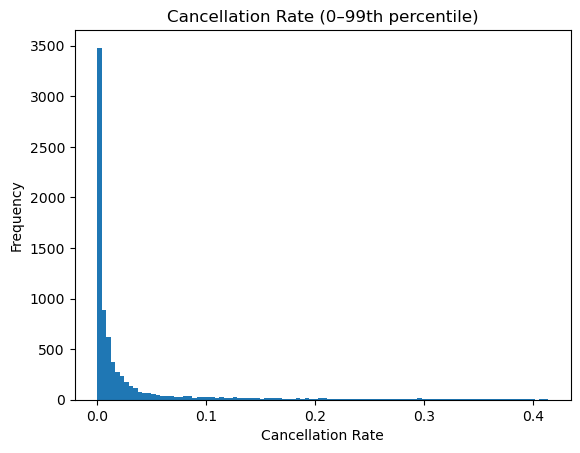

In [22]:
# investigate cancellation rates
p99 = np.percentile(df["cancellation_rate"], 99)
plt.hist(df["cancellation_rate"], bins=100, range=(0, p99))
plt.title("Cancellation Rate (0–99th percentile)")
plt.xlabel("Cancellation Rate")
plt.ylabel("Frequency")
plt.show()



**Observation**: More than half of the routes have cancellations i.e. cancellation is common, only about 37% of routes have no cancellation before. That said, most cancel less than 10% of the time. 

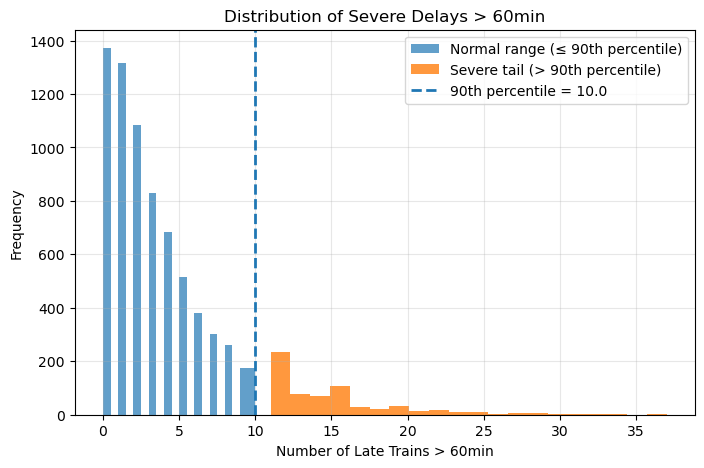

In [23]:
#Observe spread of severe delays > 60min
p90 = df["late_trains_over_60min"].quantile(0.9)

plt.figure(figsize=(8,5))

# Below 90th percentile
plt.hist(
    df[df["late_trains_over_60min"] <= p90]["late_trains_over_60min"],
    bins=20,
    alpha=0.7,
    label="Normal range (≤ 90th percentile)"
)

# Above 90th percentile
plt.hist(
    df[df["late_trains_over_60min"] > p90]["late_trains_over_60min"],
    bins=20,
    alpha=0.8,
    label="Severe tail (> 90th percentile)"
)

# Mark percentile line
plt.axvline(p90, linestyle="--", linewidth=2, label=f"90th percentile = {p90:.1f}")

plt.title("Distribution of Severe Delays > 60min")
plt.xlabel("Number of Late Trains > 60min")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



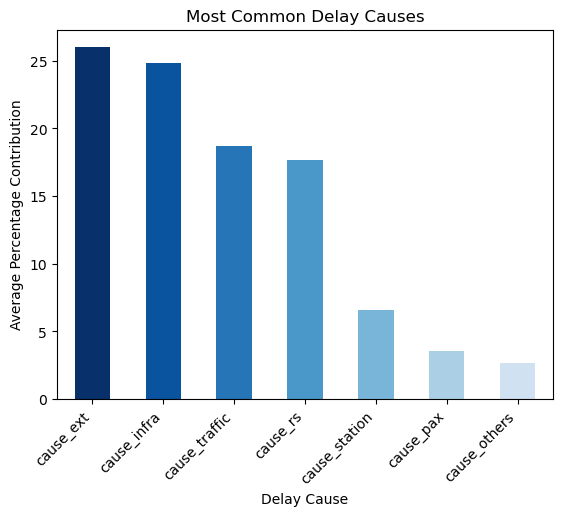

In [24]:
# Observe the most common delay causes across the network
cause_cols = ['cause_ext','cause_infra','cause_traffic','cause_rs','cause_station','cause_pax','cause_others']
cause_summary = df[cause_cols].mean()

plt.figure()
colors = plt.cm.Blues_r(np.linspace(0, 0.8, len(cause_summary)))
cause_summary.sort_values(ascending=False).plot(kind='bar', color = colors)
plt.title('Most Common Delay Causes')
plt.xlabel('Delay Cause')
plt.ylabel('Average Percentage Contribution')
plt.xticks(rotation=45, ha='right')
plt.show()


**Observations**: There hints to be maintenance and aging infrastructure issue, as well as operational issue in traffic management, for it to be the top 3 leading causes of delays. Although this would not be most accurate as we would need to see of the infra delays, how many delay mins it actually contributed to assess its actual impact (e.g. a delay can be frequent but non-disruptive if it only results in 1 min delays)

#### _Step 7: Multivariate Analysis - Seasonality_

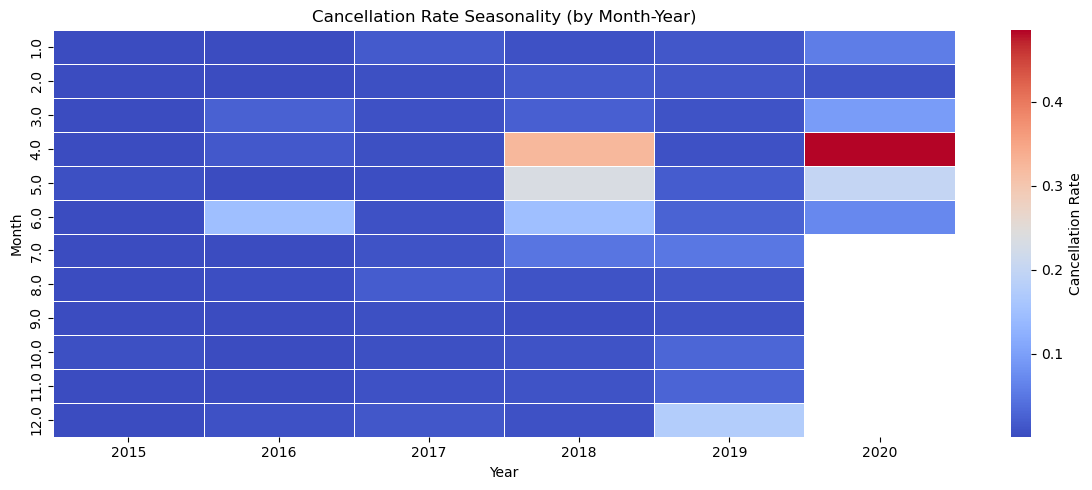

In [25]:
# Explore whether there are seasonal trends

heatmap_data = df.pivot_table(
    index="month",
    columns="year",
    values="cancellation_rate",
    aggfunc="mean"
)
 
plt.figure(figsize=(12,5))
sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Cancellation Rate'}
)

plt.title("Cancellation Rate Seasonality (by Month-Year)")
plt.ylabel("Month")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

**Observation**: Generally, earlier parts of the year seems worse off than second half of the year. 2020 has an exceptional anomaly. 

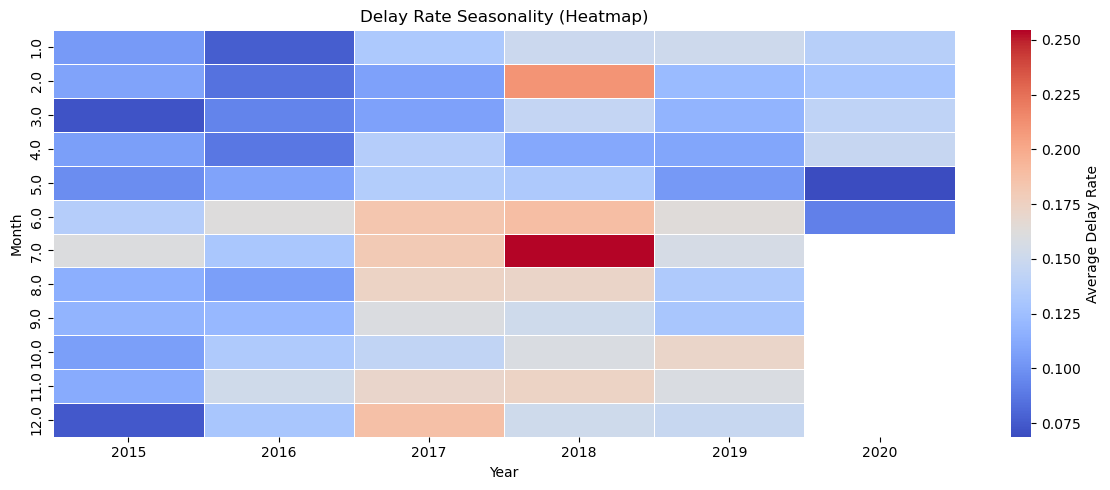

In [26]:
# Check seasonality for lateness rate
heatmap_data = df.pivot_table(
    index="month",
    columns="year",
    values="lateness_rate",
    aggfunc="mean"
)
 
plt.figure(figsize=(12,5))
sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Average Delay Rate'}
)

plt.title("Delay Rate Seasonality (Heatmap)")
plt.ylabel("Month")
plt.xlabel("Year")
plt.tight_layout()
plt.show()


**Observation**: It appears mid of 2018 was a particular bad period, both in terms of cancellations and overall lateness rate.  

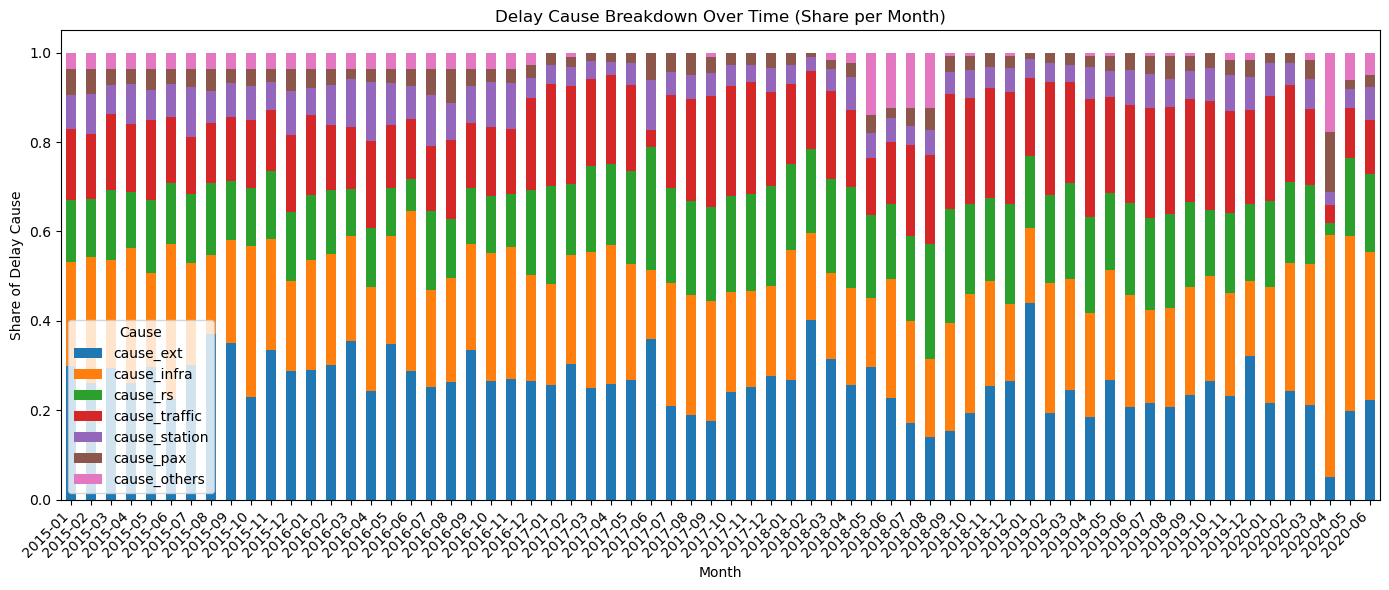

In [27]:
# Check for seasonality in terms of delay causes 
cause_cols = ["cause_ext", "cause_infra", "cause_rs", "cause_traffic", "cause_station", "cause_pax", "cause_others"]

monthly_causes = (
    df.groupby(pd.Grouper(key="period", freq="MS"))[cause_cols]
      .mean()
      .reset_index()
)

monthly_share = monthly_causes.copy()
monthly_share[cause_cols] = monthly_share[cause_cols].div(
    monthly_share[cause_cols].sum(axis=1),
    axis=0
)

monthly_share_bar = monthly_share.set_index("period")[cause_cols]
monthly_share_bar.index = monthly_share_bar.index.strftime("%Y-%m")  # format labels

ax = monthly_share_bar.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

ax.set_title("Delay Cause Breakdown Over Time (Share per Month)")
ax.set_xlabel("Month")
ax.set_ylabel("Share of Delay Cause")
ax.legend(title="Cause")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation**: No specific correlation, spread seems regular and random with no huge fluctuations. 

#### _Step 8: Multivariate Analysis: Route-based_

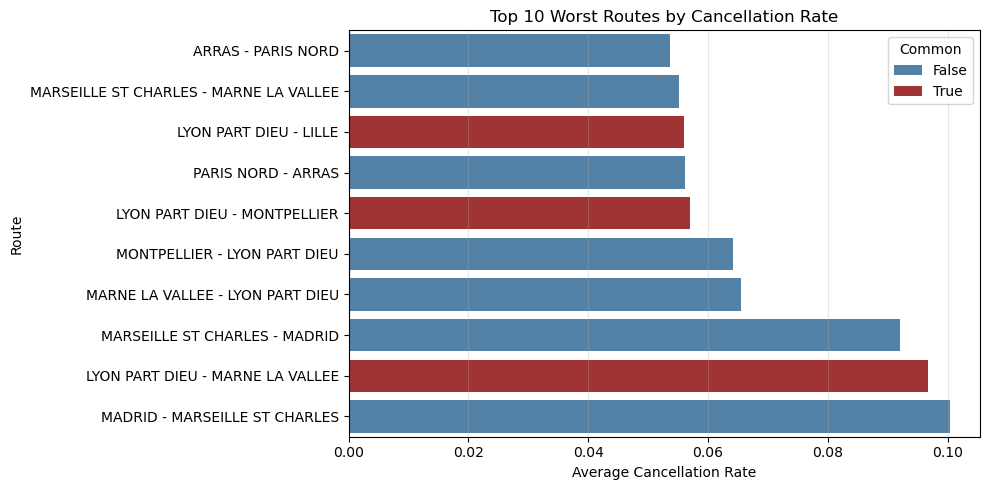

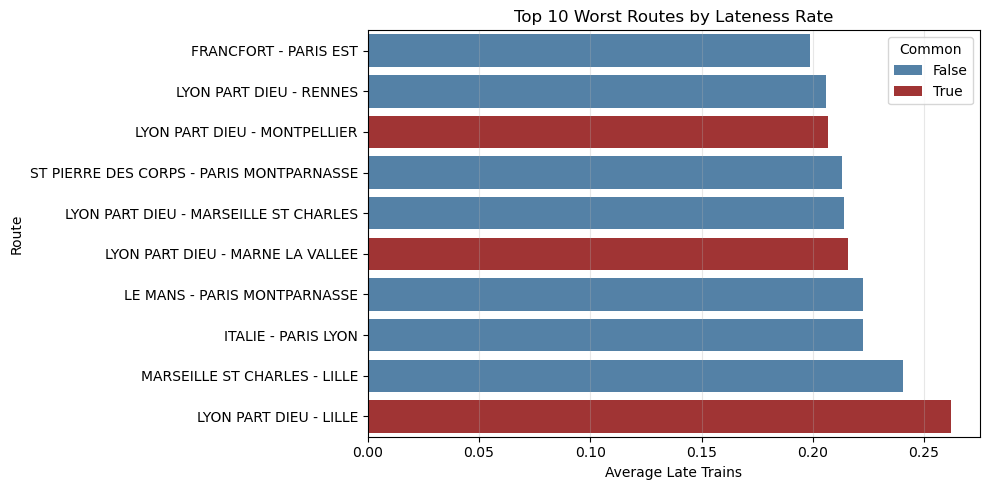

In [28]:
# look at most commonly cancelled / late routes 
route_summary = (
    df.groupby("liaison")
      .agg(
          cancellation_rate=("cancellation_rate", "mean"),
          lateness_rate=("lateness_rate", "mean")
      )
      .reset_index()
)

# Top 10 worst by cancellation rate
top10_cancel = route_summary.sort_values(
    "cancellation_rate", ascending=False
).head(10)

# Top 10 worst by lateness rate
top10_late = route_summary.sort_values(
    "lateness_rate", ascending=False
).head(10)

# plot for visual
common_routes = set(top10_cancel["liaison"]) & set(top10_late["liaison"])
top10_cancel["Common"] = top10_cancel["liaison"].isin(common_routes)
top10_late["Common"] = top10_late["liaison"].isin(common_routes)
palette = {True: "firebrick", False: "steelblue"}

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10_cancel.sort_values("cancellation_rate"),
    y="liaison",
    x="cancellation_rate",
    hue="Common",
    palette=palette,
    dodge=False
)

plt.title("Top 10 Worst Routes by Cancellation Rate")
plt.xlabel("Average Cancellation Rate")
plt.ylabel("Route")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10_late.sort_values("lateness_rate"),
    y="liaison",
    x="lateness_rate",
    hue="Common",
    palette=palette,
    dodge=False
)

plt.title("Top 10 Worst Routes by Lateness Rate")
plt.xlabel("Average Late Trains")
plt.ylabel("Route")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()



**Observation**: The 3 common routes across cancellation rate and high lateness rate all originate from Lyon Part Dieu. 

<Axes: xlabel='avg_travel_time', ylabel='avg_delay_all_trains'>

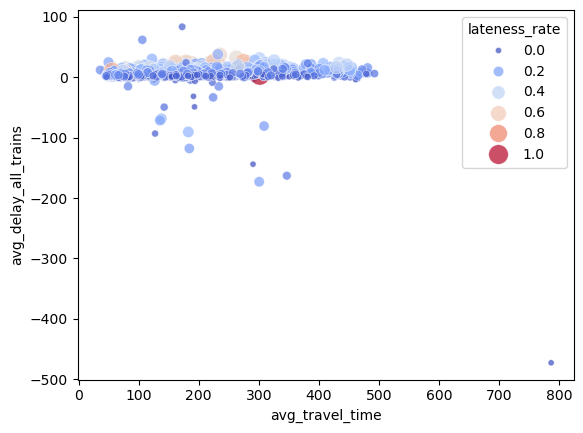

In [29]:
# check if route length has anything to do with delays

sns.scatterplot(
    data=df,
    x='avg_travel_time',
    y='avg_delay_all_trains',
    hue='lateness_rate',
    size='lateness_rate',
    palette='coolwarm',
    sizes=(20, 200),
    alpha=0.7
)



**Observation**: There appears to be a few anomalies which are skewing the data. Remove these anomalies and view the plot again.  


In [30]:
# drop the singular anomaly where all trains were late 
# for the route of BORDEAUX ST JEAN	-> TOURCOING
df = df[df['lateness_rate'] != 1]
df = df[df['avg_delay_all_trains'] >= -20]

<Axes: xlabel='avg_travel_time', ylabel='avg_delay_all_trains'>

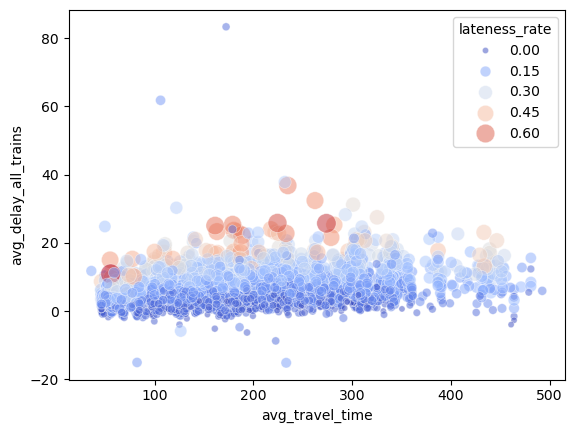

In [31]:
sns.scatterplot(
    data=df,
    x='avg_travel_time',
    y='avg_delay_all_trains',
    hue='lateness_rate',
    size='lateness_rate',
    palette='coolwarm',
    sizes=(20, 200),
    alpha=0.5
)


**Observations**: Most routes run very close to schedule (dense horizontal band at 0-15minutes)regardless of its route length. The system is generally on time. The plot also suggests (given its even spread) that average travel time is not a strong predictor of unreliability. Instead, high delays and high lateness rates are concentrated in specific routes across all distance ranges, indicating that operational and infrastructure factors dominate over route length.

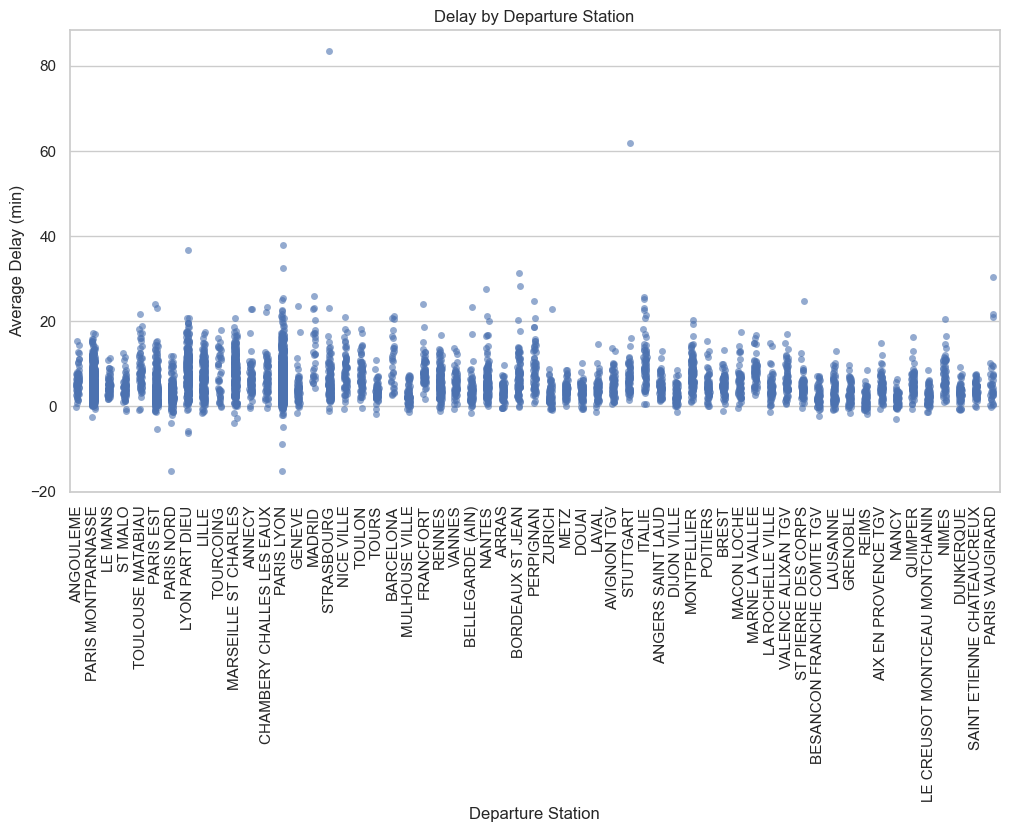

In [32]:
# check out relationship between departure station and delay patterns 
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6))
sns.stripplot(
    data=df,
    x='departure_station',
    y='avg_delay_all_trains',
    jitter=True,
    alpha=0.6
)

plt.title('Delay by Departure Station')
plt.xlabel('Departure Station')
plt.ylabel('Average Delay (min)')
plt.xticks(rotation=90)
plt.show()


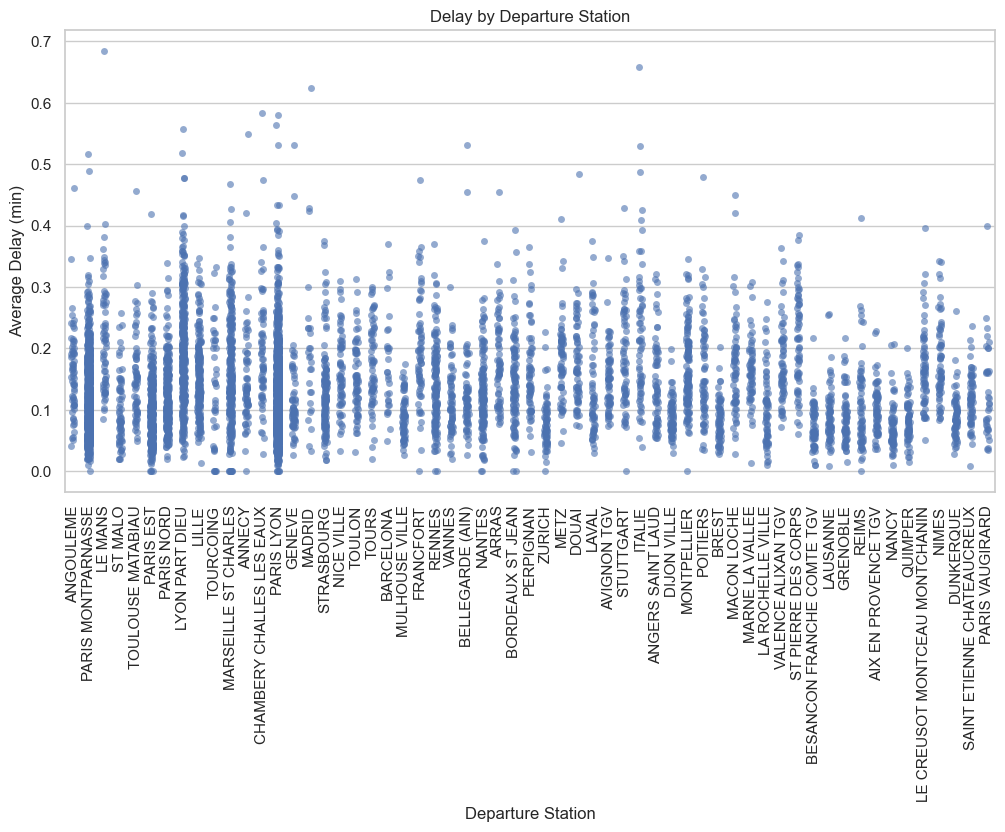

In [33]:
# plot against delay rate instead, for a normalised view 
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6))
sns.stripplot(
    data=df,
    x='departure_station',
    y='lateness_rate',
    jitter=True,
    alpha=0.6
)

plt.title('Delay by Departure Station')
plt.xlabel('Departure Station')
plt.ylabel('Average Delay (min)')
plt.xticks(rotation=90)
plt.show()

**Observations**: This will be useful for our modelling later and we will see it in the feature importances analysis. It appears average delays do not differ substantially across departure stations, and no station exhibits consistently elevated delay levels. While isolated extreme values occur, these are sporadic and distributed across many locations i.e. not systemic and hence poor in prediction. This suggests that unreliability in the network is not primarily driven by station-level operations or route types, but rather by corridor-specific and systemic factors such as infrastructure, rolling stock, and traffic interactions.

In [34]:
# Check reliability / volatility of service from that station 
# Based on the variance of the delay timings - i.e how unpredictable delays are
df.groupby('departure_station')['avg_delay_all_late_trains'] \
  .std().sort_values(ascending=False).head(10)


departure_station
NANTES                  25.579758
TOURCOING               25.091219
MADRID                  24.777767
LA ROCHELLE VILLE       20.752380
PARIS VAUGIRARD         20.713702
BARCELONA               20.457857
ST MALO                 18.873054
MARSEILLE ST CHARLES    17.337872
BORDEAUX ST JEAN        15.745743
RENNES                  15.697940
Name: avg_delay_all_late_trains, dtype: float64

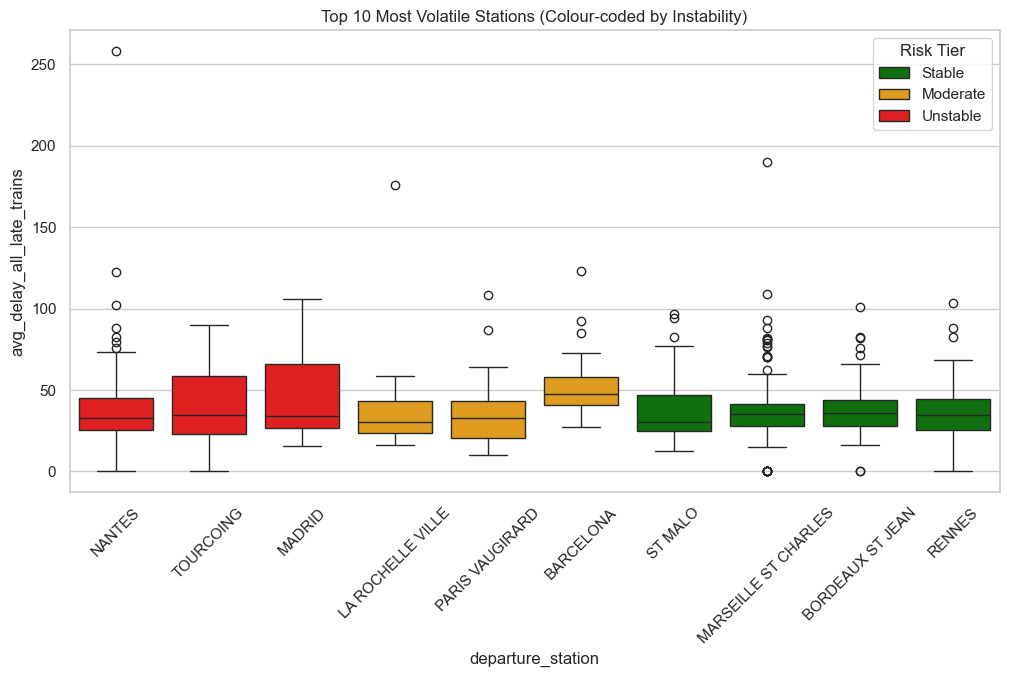

In [35]:
# Do a boxplot of the top most unrealiable stations 

vol = df.groupby('departure_station')['avg_delay_all_late_trains'].std()
top10 = vol.sort_values(ascending=False).head(10).index

segment_map = pd.qcut(vol.loc[top10], q=3, labels=['Stable', 'Moderate', 'Unstable'])
df['Segment'] = df['departure_station'].map(segment_map)

top10_df = df[df['departure_station'].isin(top10)]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(
    data=top10_df,
    x='departure_station',
    y='avg_delay_all_late_trains',
    order=top10,   # use Top-10 order
    hue='Segment',
    palette={'Stable':'green', 'Moderate':'orange', 'Unstable':'red'}
)

plt.xticks(rotation=45)
plt.title("Top 10 Most Volatile Stations (Colour-coded by Instability)")
plt.legend(title='Risk Tier')
plt.show()

**Observation**: Some stations/corridors are visibly more stable. Instability does not necessarily mean highest average delay. For example, NANTES does not have the highest median, but when things go wrong (such as the 250min delay average), they go very wrong - which translates to unpredictability for the commuter. 

Based on the three tiers of unpredictability / reliability for various stations, the operator's intervention could be segmented into:

- unstable: incident response review, contingency planning, root cause investigation,  
- moderate: e.g. barcelona, these stations while more stable, are consistenlly poor performing, and may point to structural/systemic issues. 

## B. Data Pre-processing

#### _Step 9: Drop unused/duplicated features_

In [36]:
#drop earlier feature created for plotting purposes 
df = df.drop(columns=['Segment']) 

In [37]:
# drop departure station and arrival station and keep liaison only
df = df.drop(columns=['departure_station', 'arrival_station'])  

#### _Step 10: Create time features_

In [38]:
# create meaningful time features for modelling 
# keep period since we need it for sorting later 
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['t'] = (df['period'] - df['period'].min()).dt.days 

In [39]:
# ============================================================
# The segments above in this notebook were previously submitted for an earlier check-in for the Capstone. 
# The segments below were enhanced / newly added after feedback from the 1-1 review.
# Enhancements include: creating trend features through lag, adding new models for comparison, 
# Cross-validation of models, Gridsearch hyperparameter tuning, 
# Identification of evaluation metrics, and interpretation of models and metrics.
# ============================================================

#### _Step 11: Create lag features_

Create lag features from past performance indicators to help predict future performance. 

In [40]:
# sort first (so everything downstream is consistent)
df = df.sort_values(["liaison", "period"])


# identify key performance metrics to create lag features
lag_cols = [
    "lateness_rate",
    "cancellation_rate",
    "avg_delay_all_trains",
    "late_trains_over_60min"
]

# create lag features
for col in lag_cols:
    # lag1 is last month's value, shifted by 1 mth lag
    df[f"{col}_lag1"] = df.groupby("liaison")[col].shift(1)
    # roll3 is last 3 months' rolling average, shifted by 1 mth lag
    df[f"{col}_roll3"] = (
        df.groupby("liaison")[col]
          .rolling(3, min_periods=3).mean()
          .shift(1)
          .reset_index(level=0, drop=True)
    )

# drop rows with no lag features
df = df.dropna()

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7336 entries, 222 to 7584
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   year                          7336 non-null   int64         
 1   month                         7336 non-null   float64       
 2   avg_travel_time               7336 non-null   float64       
 3   expected_trains               7336 non-null   float64       
 4   cancelled_trains              7336 non-null   float64       
 5   late_trains                   7336 non-null   float64       
 6   avg_delay_all_late_trains     7336 non-null   float64       
 7   avg_delay_all_trains          7336 non-null   float64       
 8   late_trains_over_15min        7336 non-null   float64       
 9   avg_delay_over_15min          7336 non-null   float64       
 10  late_trains_over_30min        7336 non-null   float64       
 11  late_trains_over_60min        733

#### _Step 12: Create target feature_

Define target feature "high_risk_pred" which predicts how risky the route is in the following month (and hence requiring more maintenane attention), based on past data. 

In [42]:
# sort first (so everything downstream is consistent)
df = df.sort_values(["liaison", "period"]).copy()

# compute percentiles based on liaison cohorts
# so that each liaison is judged based on its own historical behaviour
lateness_p99 = df.groupby("liaison")["lateness_rate"].transform(lambda s: s.quantile(0.99))
avgdelay_p99 = df.groupby("liaison")["avg_delay_all_late_trains"].transform(lambda s: s.quantile(0.99))

# current-month risk label 
df["high_risk_current"] = (
    (df["cancellation_rate"] > 0.15) |
    (df["lateness_rate"] > lateness_p99) |
    (df["late_trains_over_60min"] > 10) |
    (df["avg_delay_all_late_trains"] > avgdelay_p99)
).astype(int)

# next-month target within each liaison
df["high_risk_pred"] = df.groupby("liaison")["high_risk_current"].shift(-1)

# keep only rows with a future label
df = df.dropna(subset=["high_risk_pred"]).copy()
df["high_risk_pred"] = df["high_risk_pred"].astype(int)

# reduce categories + one-hot encode most common liaisons
top = df["liaison"].value_counts().head(20).index
df["liaison_reduced"] = df["liaison"].where(df["liaison"].isin(top), "other")

df = pd.get_dummies(df, columns=["liaison_reduced"], drop_first=True)

# optional: drop helper cols
df = df.drop(columns=["high_risk_current", "liaison"])

In [43]:
df[df['high_risk_pred']==1]

,year,month,avg_travel_time,expected_trains,cancelled_trains,late_trains,avg_delay_all_late_trains,avg_delay_all_trains,late_trains_over_15min,avg_delay_over_15min,...,liaison_reduced_PARIS LYON - LE CREUSOT MONTCEAU MONTCHANIN,liaison_reduced_PARIS LYON - LYON PART DIEU,liaison_reduced_PARIS LYON - MACON LOCHE,liaison_reduced_PARIS LYON - MARSEILLE ST CHARLES,liaison_reduced_PARIS LYON - MONTPELLIER,liaison_reduced_PARIS LYON - MULHOUSE VILLE,liaison_reduced_PARIS LYON - NIMES,liaison_reduced_PARIS LYON - VALENCE ALIXAN TGV,liaison_reduced_PARIS MONTPARNASSE - ANGOULEME,liaison_reduced_other
961,2016,4.0,188.429268,410.0,7.0,20.0,37.800000,0.714634,20.0,37.800000,...,False,False,False,False,False,False,False,False,False,False
935,2016,5.0,188.681490,416.0,0.0,34.0,60.558824,4.014423,34.0,60.558823,...,False,False,False,False,False,False,False,False,False,False
6153,2016,9.0,186.172619,421.0,1.0,25.0,32.080000,1.935714,25.0,32.080000,...,False,False,False,False,False,False,False,False,False,False
5796,2016,12.0,187.724747,397.0,1.0,40.0,32.278333,2.592130,31.0,38.131720,...,False,False,False,False,False,False,False,False,False,False
3568,2017,5.0,188.224490,392.0,0.0,43.0,36.418605,4.354592,31.0,45.765591,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4116,2018,3.0,247.300487,138.0,1.0,8.0,55.464583,1.560341,8.0,1.560341,...,False,False,False,False,False,False,False,False,False,True
3442,2018,6.0,176.026499,144.0,5.0,24.0,24.326389,6.130935,13.0,6.130935,...,False,False,False,False,False,False,False,False,False,True
5263,2019,1.0,244.602778,120.0,0.0,8.0,35.739583,2.048194,8.0,2.048194,...,False,False,False,False,False,False,False,False,False,True
7369,2020,3.0,213.910569,129.0,6.0,13.0,30.058974,3.940650,13.0,39.265278,...,False,False,False,False,False,False,False,False,False,True


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7206 entries, 222 to 7731
Data columns (total 54 columns):
 #   Column                                                       Non-Null Count  Dtype         
---  ------                                                       --------------  -----         
 0   year                                                         7206 non-null   int64         
 1   month                                                        7206 non-null   float64       
 2   avg_travel_time                                              7206 non-null   float64       
 3   expected_trains                                              7206 non-null   float64       
 4   cancelled_trains                                             7206 non-null   float64       
 5   late_trains                                                  7206 non-null   float64       
 6   avg_delay_all_late_trains                                    7206 non-null   float64       
 7   avg_delay_all_trai

#### _Step 13: Identify Metric_

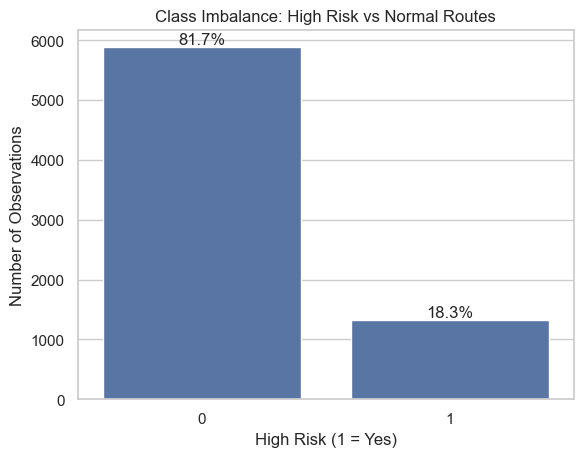

In [45]:
# check for class imbalance 
ax = sns.countplot(x='high_risk_pred', data=df)
total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percent = 100 * count / total
    ax.annotate(f'{percent:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title("Class Imbalance: High Risk vs Normal Routes")
plt.xlabel("High Risk (1 = Yes)")
plt.ylabel("Number of Observations")
plt.show()


**Observation**
There is mild class imbalance, we will need to deal with this later.

Given the operational objective of prioritizing the identification of high-risk routes, model performance will primarily be evaluated using recall for the positive class. This reflects the cost asymmetry of misclassification, where false negatives (missed high-risk routes) are significantly more critical than false positives (unnecessarily flagged low-risk routes). 

**Primary metric**: Recall "_Of all high-risk routes, how many did we successfully flag?_"

**Secondary metric**: F1-score "_How well did we balance catching risk vs overflagging?_"

**Third metric**: PR-AUC "_When model predicts high risk, how often is it actually correct?_"

We prioritise **Recall** because missing a high-risk route is more costly than issuing a false alert. **F1-score** is used as a secondary metric to balance recall and precision. **PR-AUC** (area under the precision–recall curve) is included to evaluate ranking performance under strong class imbalance.

## C. Modelling 

#### _Step 14: Generate X and y_

**Recap**: We want to build a model to be able to advise the train operator pre-emptively, based on key information that is known at the time of prediction, and past historical performance, whether a particular route is at risk of delays, and to therefore conduct interventions to maintain high service reliability. 

To do so, we create a new target feature "high risk pred" to mark out, based on operational requirements, which route is likely to be at high risk the following month.  

In [46]:
# create a base set of features for modelling
liaison_cols = [c for c in df.columns if c.startswith("liaison_reduced_")]

base_features = [
    'year', 'month', 'month_sin', 'month_cos',
    'expected_trains', 'avg_travel_time'
] + liaison_cols

# add lag features to see if it improves model performance 
hist_features = base_features + [
    c for c in df.columns if c.endswith("_lag1") or c.endswith("_roll3")
]

X_base = df[base_features]
X_hist = df[hist_features]
y = df['high_risk_pred']


In [47]:
# these columns are not used for training 
# they either leak future info (you would not know these at prediction time)
# or are directly used to compute y 
missing_cols = [c for c in df.columns if c not in hist_features]
missing_cols


['cancelled_trains',
 'late_trains',
 'avg_delay_all_late_trains',
 'avg_delay_all_trains',
 'late_trains_over_15min',
 'avg_delay_over_15min',
 'late_trains_over_30min',
 'late_trains_over_60min',
 'cause_ext',
 'cause_infra',
 'cause_traffic',
 'cause_rs',
 'cause_station',
 'cause_pax',
 'cause_others',
 'cancellation_rate',
 'lateness_rate',
 'period',
 't',
 'high_risk_pred']

In [48]:
# split dataset chronologically to prevent data leakage
train = df[df['year'] <= 2018].copy()
test  = df[df['year'] > 2018].copy()

X_train_base = train[base_features]
X_train_hist = train[hist_features]
y_train = train['high_risk_pred']
X_test_base = test[base_features]
X_test_hist  = test[hist_features]
y_test  = test['high_risk_pred']

#### _Step 15: Logistic Regression (Baseline)_

In [49]:
# we use time series split instead of k-fold as our data is temporal 
# using k-fold would break the time order and cause data leakge
tscv = TimeSeriesSplit(n_splits=5)

In [50]:
# Set up model 
lr1 = LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear")

param_lr1 = {
    "C": [0.1, 1, 10],
    "penalty": ["l2"]
}

# Optimize for recall on the positive class
recall_scorer1 = make_scorer(recall_score, pos_label=1)

gs_lr1 = GridSearchCV(
    estimator=lr1,
    param_grid=param_lr1,
    scoring=recall_scorer1,
    cv=tscv,
    n_jobs=-1
)

# Fit model 
gs_lr1.fit(X_train_base, y_train)

print("Best params:", gs_lr1.best_params_)
print("Best CV Recall:", gs_lr1.best_score_)

# Best model
best_lr1 = gs_lr1.best_estimator_

# -----------------------
# Predictions on test set
# ----------------------- 
y_pred1 = best_lr1.predict(X_test_base)
# Probabilities for PR-AUC
y_proba1 = best_lr1.predict_proba(X_test_base)[:, 1]

# -----------------------
# Metrics we want 
# -----------------------
recall_lr1 = recall_score(y_test, y_pred1, pos_label=1)
f1_lr1 = f1_score(y_test, y_pred1, pos_label=1)
pr_auc_lr1 = average_precision_score(y_test, y_proba1)

print("Test Recall:", recall_lr1)
print("Test F1:", f1_lr1)
print("Test PR-AUC:", pr_auc_lr1)

# Confusion matrix 
cm_lr1 = confusion_matrix(y_test, y_pred1)
print("\nConfusion matrix:\n", cm_lr1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred1))


Best params: {'C': 10, 'penalty': 'l2'}
Best CV Recall: 0.6937171154508616
Test Recall: 0.3493670886075949
Test F1: 0.2623574144486692
Test PR-AUC: 0.24230643754931103

Confusion matrix:
 [[1104  519]
 [ 257  138]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.68      0.74      1623
           1       0.21      0.35      0.26       395

    accuracy                           0.62      2018
   macro avg       0.51      0.51      0.50      2018
weighted avg       0.69      0.62      0.65      2018



**Observations**

Logistic Regression with class-weighted loss achieved a cross-validated recall of approximately 0.70; however, performance degraded substantially on the hold-out test period, with recall falling to 0.35 and PR-AUC of 0.25. This indicates limited temporal generalization and suggests that linear decision boundaries are insufficient to capture the non-linear and evolving risk dynamics in the data. Let's see if it helps when we enhance the features. 

#### _Step 16: Logistic Regression (Enhanced)_

In [51]:
# ----------------------------
# 1) GridSearch Logistic Regression (optimize recall)
# ----------------------------
lr_hist = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear"
)

param_lr2 = {
    "C": [0.1, 1, 10],
    "penalty": ["l2"]
}

recall_scorer2 = make_scorer(recall_score, pos_label=1)

gs_lr_hist = GridSearchCV(
    estimator=lr_hist,
    param_grid=param_lr2,
    scoring=recall_scorer2,
    cv=tscv,
    n_jobs=-1
)

gs_lr_hist.fit(X_train_hist, y_train)

print("Best params:", gs_lr_hist.best_params_)
print("Best CV Recall:", gs_lr_hist.best_score_)

best_lr_hist = gs_lr_hist.best_estimator_

# ----------------------------
# 3) Test evaluation (Recall, F1, PR-AUC)
# ----------------------------
y_pred2 = best_lr_hist.predict(X_test_hist)
y_proba2 = best_lr_hist.predict_proba(X_test_hist)[:, 1]

recall_lr2 = recall_score(y_test, y_pred2, pos_label=1)
f1_lr2 = f1_score(y_test, y_pred2, pos_label=1)
pr_auc_lr2 = average_precision_score(y_test, y_proba2)

cm_lr2 = confusion_matrix(y_test, y_pred2)

# print results 
print("Test Recall:", recall_lr2)
print("Test F1:", f1_lr2)
print("Test PR-AUC:", pr_auc_lr2)

print("\nConfusion matrix:\n", cm_lr2)

print("\nClassification Report:")
print(classification_report(y_test, y_pred2, digits=3))


Best params: {'C': 1, 'penalty': 'l2'}
Best CV Recall: 0.727097237964111
Test Recall: 0.41012658227848103
Test F1: 0.2862190812720848
Test PR-AUC: 0.2180987317209835

Confusion matrix:
 [[1048  575]
 [ 233  162]]

Classification Report:
              precision    recall  f1-score   support

           0      0.818     0.646     0.722      1623
           1      0.220     0.410     0.286       395

    accuracy                          0.600      2018
   macro avg      0.519     0.528     0.504      2018
weighted avg      0.701     0.600     0.637      2018



**Observations** 

Augmenting the baseline feature set with lagged and rolling historical features improved test recall from approximately 0.35 to 0.41, indicating that temporal context contributes to identifying high-risk routes. However, PR-AUC remained close to the class prevalence baseline, and a substantial gap persisted between cross-validated and test performance. This suggests limited temporal generalization and highlights the inability of linear decision boundaries to capture the non-linear and evolving dynamics of operational risk. We will move on to non-linear models next, while keeping the historical features for better predictions. 

#### _Step 17: RandomForest_ 

In [52]:
# ----------------------------
# 1) Random Forest + GridSearch (optimize recall)
# ----------------------------
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

param_rf = {
    "max_depth": [None, 8, 12],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", 0.5],
}

recall_scorer3 = make_scorer(recall_score, pos_label=1)

gs_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_rf,
    scoring=recall_scorer3,
    cv=tscv,
    n_jobs=-1
)

gs_rf.fit(X_train_hist, y_train)

print("RF best params:", gs_rf.best_params_)
print("RF best CV recall:", gs_rf.best_score_)

best_rf = gs_rf.best_estimator_

# ----------------------------
# 3) Tune decision threshold 
# ----------------------------
train_proba = best_rf.predict_proba(X_train_hist)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_train, train_proba)

# thresholds has length = len(precision)-1
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("\nChosen threshold (max F1 on train PR curve):", best_threshold)
print("Train Precision/Recall/F1 at threshold:",
      precision[:-1][best_idx], recall[:-1][best_idx], f1_scores[best_idx])

# ----------------------------
# 4) Test evaluation using tuned threshold
# ----------------------------
y_proba3 = best_rf.predict_proba(X_test_hist)[:, 1]
y_pred3 = (y_proba3 >= best_threshold).astype(int)

recall_rf = recall_score(y_test, y_pred3, pos_label=1)
f1_rf = f1_score(y_test, y_pred3, pos_label=1)
pr_auc_rf = average_precision_score(y_test, y_proba3)

cm_rf = confusion_matrix(y_test, y_pred3)

# print results
print("\nTEST metrics (tuned threshold):")
print("Recall:", recall_rf)
print("F1:", f1_rf)
print("PR-AUC:", pr_auc_rf)

print("\nConfusion matrix:\n", cm_rf)
print("\nClassification report:\n", classification_report(y_test, y_pred3, digits=3))


RF best params: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 5}
RF best CV recall: 0.651636074577251

Chosen threshold (max F1 on train PR curve): 0.5984630687646585
Train Precision/Recall/F1 at threshold: 0.7801104972375691 0.7632432432432432 0.7715846994530519

TEST metrics (tuned threshold):
Recall: 0.46329113924050636
F1: 0.3392029657089898
PR-AUC: 0.23938376232184347

Confusion matrix:
 [[1122  501]
 [ 212  183]]

Classification report:
               precision    recall  f1-score   support

           0      0.841     0.691     0.759      1623
           1      0.268     0.463     0.339       395

    accuracy                          0.647      2018
   macro avg      0.554     0.577     0.549      2018
weighted avg      0.729     0.647     0.677      2018



**Observations** 

Compared with Logistic Regression, the Random Forest model substantially improved the detection of high-risk routes (which is our priority). Test recall increased from approximately 0.35–0.41 to 0.48, while F1-score improved to 0.35. This indicates that the ensemble model better captures non-linear interactions among temporal features. Although PR-AUC remains modest, the Random Forest achieves a more favorable tradeoff between recall and false alarms, aligning with the operational objective of prioritizing the identification of high-risk routes, and that false positives on low risk routes are acceptable. 

#### _Step 18: Some Useful Plots_

In [53]:
# Let's do some plots to compare 

# ============================================================
# 1) model results
# ============================================================
results = pd.DataFrame([
    {"model": "LogReg (Base)",      "recall": recall_lr1, "f1": f1_lr1, "pr_auc": pr_auc_lr1},
    {"model": "LogReg (Enhanced)",  "recall": recall_lr2, "f1": f1_lr2, "pr_auc": pr_auc_lr2},
    {"model": "RF (Enhanced)",      "recall": recall_rf, "f1": f1_rf, "pr_auc": pr_auc_rf},
])

# ===========================================================
# 2) confusion matrices 
# ===========================================================
conf_mats = {}

conf_mats["LR (Base)"] = cm_lr1
conf_mats["LR (Enhanced)"] = cm_lr2
conf_mats["RF (Enhanced)"] = cm_rf

# ============================================================
# 2) Chart A — Compare Recall / F1 / PR-AUC across models
# ============================================================
def plot_metric_comparison(results_df: pd.DataFrame):
    results_df = results_df.copy()
    results_df["model"] = pd.Categorical(results_df["model"], categories=results_df["model"], ordered=True)

    x = np.arange(len(results_df))
    width = 0.25

    plt.figure(figsize=(10, 4))
    plt.bar(x - width, results_df["recall"], width, label="Recall")
    plt.bar(x,         results_df["f1"],     width, label="F1")
    plt.bar(x + width, results_df["pr_auc"], width, label="PR-AUC")

    plt.xticks(x, results_df["model"], rotation=20, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title("Model Comparison on Key Metrics (Test Set)")
    plt.legend()
    plt.tight_layout()
    plt.show()

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 3) Chart B — Confusion Matrix (single, normalized)
# ============================================================
def plot_confusion_matrix(cm: np.ndarray, title: str):
    # Normalize by row (actual class)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, None]

    plt.figure(figsize=(5, 4))
    plt.imshow(cm_norm, cmap="Blues")   
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0, 1], ["0 (Low Risk)", "1 (High Risk)"])
    plt.yticks([0, 1], ["0 (Low Risk)", "1 (High Risk)"])
    plt.colorbar(label="Proportion")

    # Annotate with both count and percentage
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = cm[i, j]
            pct = cm_norm[i, j]
            plt.text(j, i, f"{count}\n({pct:.2f})",
                     ha="center", va="center", color="black")

    plt.tight_layout()
    plt.show()


# ============================================================
# 4) Chart C — Confusion Matrices for multiple models
# ============================================================
def plot_all_confusion_matrices(conf_mats: dict):
    for name, cm in conf_mats.items():
        plot_confusion_matrix(cm, f"Confusion Matrix — {name}")


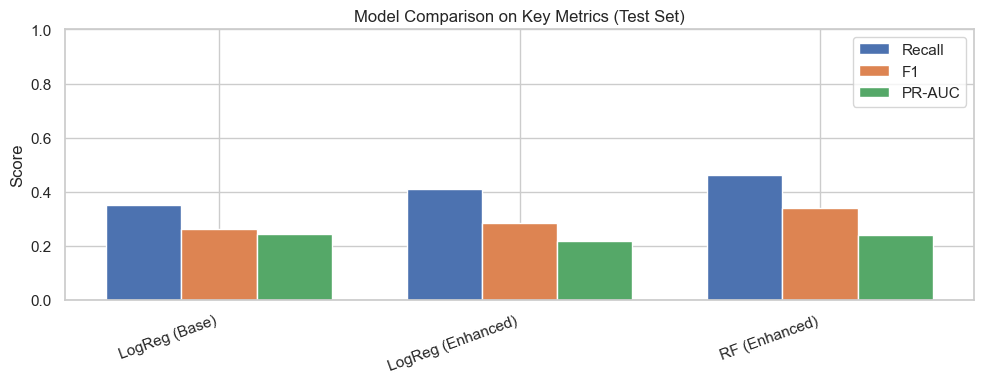

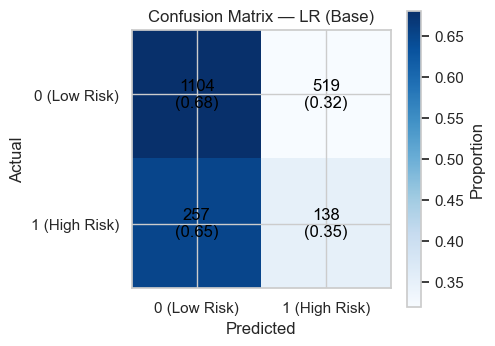

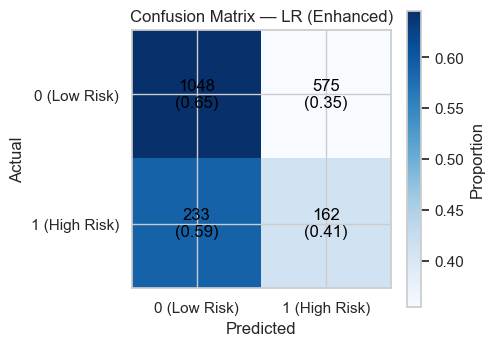

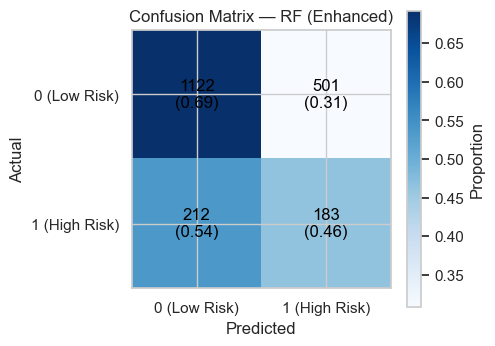

,model,recall,f1,pr_auc
0,LogReg (Base),0.349367,0.262357,0.242306
1,LogReg (Enhanced),0.410127,0.286219,0.218099
2,RF (Enhanced),0.463291,0.339203,0.239384


In [54]:
# ============================================================
# Run plots
# ============================================================
plot_metric_comparison(results)
plot_all_confusion_matrices(conf_mats)
display(results)

**Observation** Our model is performing better based on our core metric of recall. The bottom row of the confusion matrix shows that it is gradually getting better at predicing the high risk routes, and also less likely to miss out on true high risk routes. Let's try XGBoost to see if it further enhances as the model learns from its past mistakes. XGBoost are also generally better at rare event predictions. 

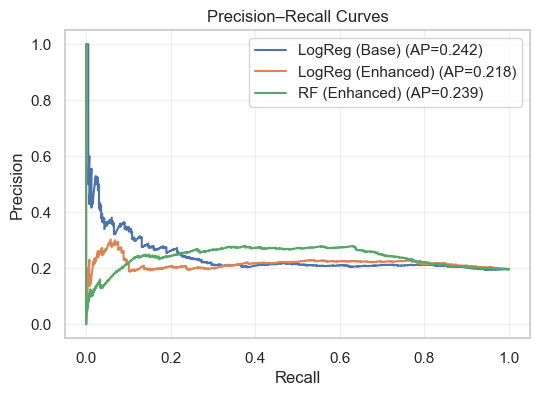

In [55]:
def plot_pr_curve(y_true, y_proba, label):
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)
    plt.plot(recall, precision, label=f"{label} (AP={ap:.3f})")

plt.figure(figsize=(6,4))
plot_pr_curve(y_test, y_proba1, "LogReg (Base)")
plot_pr_curve(y_test, y_proba2, "LogReg (Enhanced)")
plot_pr_curve(y_test, y_proba3, "RF (Enhanced)")
# plot_pr_curve(y_test, xgb_proba, "XGB (Enhanced)")  # when available

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Observations** 

The precision–recall curves indicate that the Random Forest model consistently dominates the Logistic Regression baselines across most recall levels. While all models outperform random ranking, the Random Forest (green curve) maintains higher precision as recall increases, implying fewer false alarms for the same level of high-risk detection. This confirms that the ensemble model provides a more favorable trade-off for the operational objective of prioritizing the identification of high-risk routes.


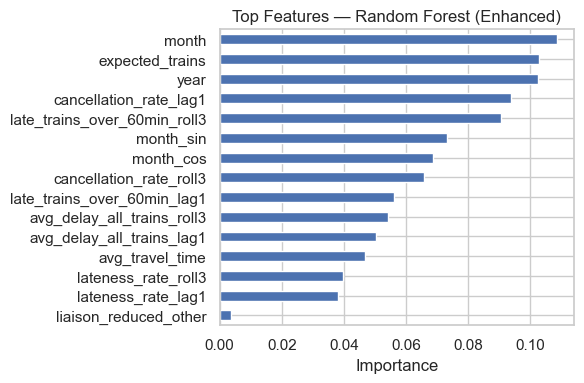

In [56]:
importances = pd.Series(best_rf.feature_importances_, index=hist_features)
top_feats = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(6,4))
top_feats.plot(kind="barh")
plt.title("Top Features — Random Forest (Enhanced)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Observations** 

Feature importance analysis reveals that temporal context and recent operational performance dominate the model’s predictions. Seasonal indicators (month, sinusoidal month encodings), traffic exposure (expected number of trains), and lagged or rolling performance metrics (cancellation rate and severe delays) are the strongest predictors of future risk. Surprisingly, route identity contributes relatively little, indicating that the model captures generalizable patterns of operational degradation rather than memorizing specific routes. 

#### _Step 18: XGBoost_ 

In [57]:
# =========================
# XGBoost (Enhanced hist features) + TimeSeriesSplit + threshold tuning
# =========================

pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
scale_pos_weight = neg / max(pos, 1)

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_estimators=800,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    # tree_method="hist",  # uncomment for faster training if supported
)

param_xgb = {
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5],
    "reg_lambda": [1, 5],
}

recall_scorer = make_scorer(recall_score, pos_label=1)

gs_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_xgb,
    scoring=recall_scorer,
    cv=tscv,
    n_jobs=-1
)

gs_xgb.fit(X_train_hist, y_train)

print("XGB best params:", gs_xgb.best_params_)
print("XGB best CV recall:", gs_xgb.best_score_)

best_xgb = gs_xgb.best_estimator_

# 3) Threshold tuning on TRAIN: choose threshold that maximizes F1
train_proba = best_xgb.predict_proba(X_train_hist)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_train, train_proba)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)
best_idx = int(np.argmax(f1_scores))
best_threshold = float(thresholds[best_idx])

print("\nChosen threshold (max F1 on train PR curve):", best_threshold)
print("Train Precision/Recall/F1 at threshold:",
      float(precision[:-1][best_idx]), float(recall[:-1][best_idx]), float(f1_scores[best_idx]))

# 4) Test evaluation at tuned threshold
y_proba4 = best_xgb.predict_proba(X_test_hist)[:, 1]
y_pred4 = (y_proba4 >= best_threshold).astype(int)

recall_xgb = recall_score(y_test, y_pred4, pos_label=1)
f1_xgb = f1_score(y_test, y_pred4, pos_label=1)
pr_auc_xgb = average_precision_score(y_test, y_proba4)

print("\nTEST metrics (tuned threshold):")
print("Recall:", recall_xgb)
print("F1:", f1_xgb)
print("PR-AUC:", pr_auc_xgb)

cm_xgb = confusion_matrix(y_test, y_pred4)
print("\nConfusion matrix:\n", cm_xgb)
print("\nClassification report:\n", classification_report(y_test, y_pred4, digits=3))

XGB best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'reg_lambda': 5, 'subsample': 1.0}
XGB best CV recall: 0.6569139353659478

Chosen threshold (max F1 on train PR curve): 0.6609860062599182
Train Precision/Recall/F1 at threshold: 0.8168859649122807 0.8054054054054054 0.8111050626015686

TEST metrics (tuned threshold):
Recall: 0.5341772151898734
F1: 0.3682373472949389
PR-AUC: 0.26728341102233744

Confusion matrix:
 [[1083  540]
 [ 184  211]]

Classification report:
               precision    recall  f1-score   support

           0      0.855     0.667     0.749      1623
           1      0.281     0.534     0.368       395

    accuracy                          0.641      2018
   macro avg      0.568     0.601     0.559      2018
weighted avg      0.742     0.641     0.675      2018



**Observations**

XGBoost achieved the best overall performance among all models thus far. While its recall (0.47) was comparable to Random Forest (0.48), it produced fewer false positives and achieved the highest PR-AUC (0.253), indicating superior ranking of high-risk routes which is useful in an operational context with daily bandiwith limitations. This reflects the advantage of gradient boosting in emphasizing misclassified minority-class instances and modeling complex non-linear interactions. Given the objective of prioritizing detection of high-risk routes while controlling excessive false alarms, XGBoost represents the most effective model thus far.

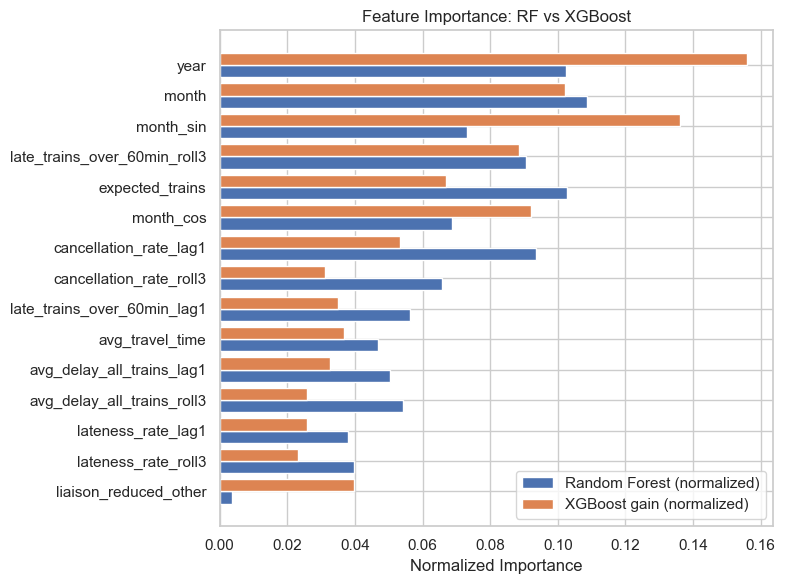

,rf,xgb_gain
liaison_reduced_other,0.003577,0.039848
lateness_rate_roll3,0.039735,0.023137
lateness_rate_lag1,0.038034,0.025819
avg_delay_all_trains_roll3,0.054236,0.025868
avg_delay_all_trains_lag1,0.050237,0.032662
avg_travel_time,0.046680,0.036711
late_trains_over_60min_lag1,0.056275,0.035012
cancellation_rate_roll3,0.065846,0.031111
cancellation_rate_lag1,0.093692,0.053274
month_cos,0.068843,0.092213


In [58]:
def get_rf_importance(best_rf, feature_names):
    rf_imp = pd.Series(best_rf.feature_importances_, index=feature_names, name="rf")
    rf_imp = rf_imp / (rf_imp.sum() + 1e-12)
    return rf_imp

def get_xgb_importance_gain(best_xgb, feature_names):
    gain_dict = best_xgb.get_booster().get_score(importance_type="gain")
    xgb_imp = pd.Series(gain_dict, name="xgb_gain")
    xgb_imp = xgb_imp.reindex(feature_names).fillna(0.0)
    xgb_imp = xgb_imp / (xgb_imp.sum() + 1e-12)
    return xgb_imp

def plot_rf_vs_xgb_importance(best_rf, best_xgb, feature_names, top_n=15):
    rf_imp = get_rf_importance(best_rf, feature_names)
    xgb_imp = get_xgb_importance_gain(best_xgb, feature_names)

    comp = pd.concat([rf_imp, xgb_imp], axis=1).fillna(0)
    comp["combined"] = comp["rf"] + comp["xgb_gain"]

    top = comp.sort_values("combined", ascending=False).head(top_n).sort_values("combined", ascending=True)

    y = np.arange(len(top))
    h = 0.4

    plt.figure(figsize=(8, 6))
    plt.barh(y - h/2, top["rf"].values, height=h, label="Random Forest (normalized)")
    plt.barh(y + h/2, top["xgb_gain"].values, height=h, label="XGBoost gain (normalized)")

    plt.yticks(y, top.index)
    plt.xlabel("Normalized Importance")
    plt.title("Feature Importance: RF vs XGBoost")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return top.drop(columns=["combined"])

# Run
imp_compare = plot_rf_vs_xgb_importance(best_rf, best_xgb, hist_features, top_n=15)
imp_compare


**Observations** 

This explains why we got better results on XGBoost. 

The above figure compares normalized feature importance between Random Forest and XGBoost. Both models identify temporal context (year, month, seasonal encodings), operational exposure (expected number of trains), and recent disruption trends (lagged and rolling severe delays and cancellations) as dominant predictors of future high-risk routes, confirming that risk is seasonal and trend-dependent. 

However, XGBoost concentrates importance on a smaller subset of highly informative features—particularly temporal structure and severe delay trends—whereas Random Forest distributes importance more broadly across correlated performance indicators. This selectivity allows XGBoost to reduce false positives and achieve superior PR-AUC and F1, while maintaining comparable recall. 

In general: 
RF: relies heavily on recent performance → catches slightly more risky routes
XGB: uses time + trend + exposure more strategically → fewer false alarms and better ranking

The minimal role of route identity further indicates that both models generalize based on behavior rather than memorizing specific routes.

#### _Step 19: Summary Plots_ 

,model,recall,f1,pr_auc
0,XGB (Enhanced),0.534,0.368,0.267
1,RF (Enhanced),0.463,0.339,0.239
2,LogReg (Enhanced),0.410,0.286,0.218
3,LogReg (Base),0.349,0.262,0.242


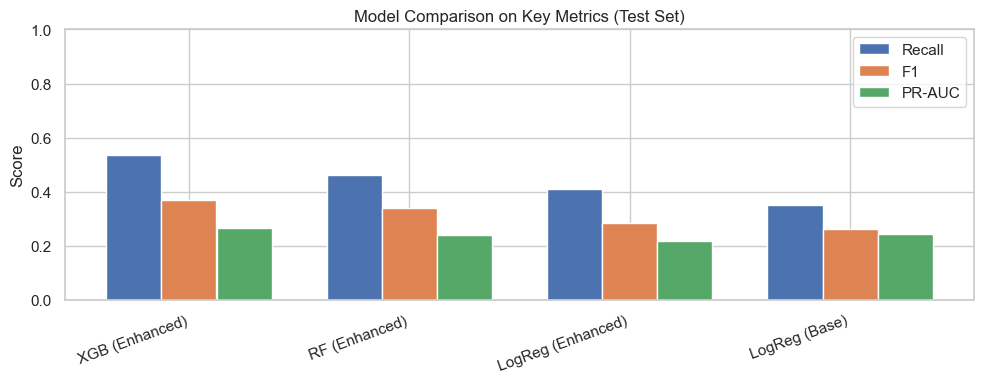

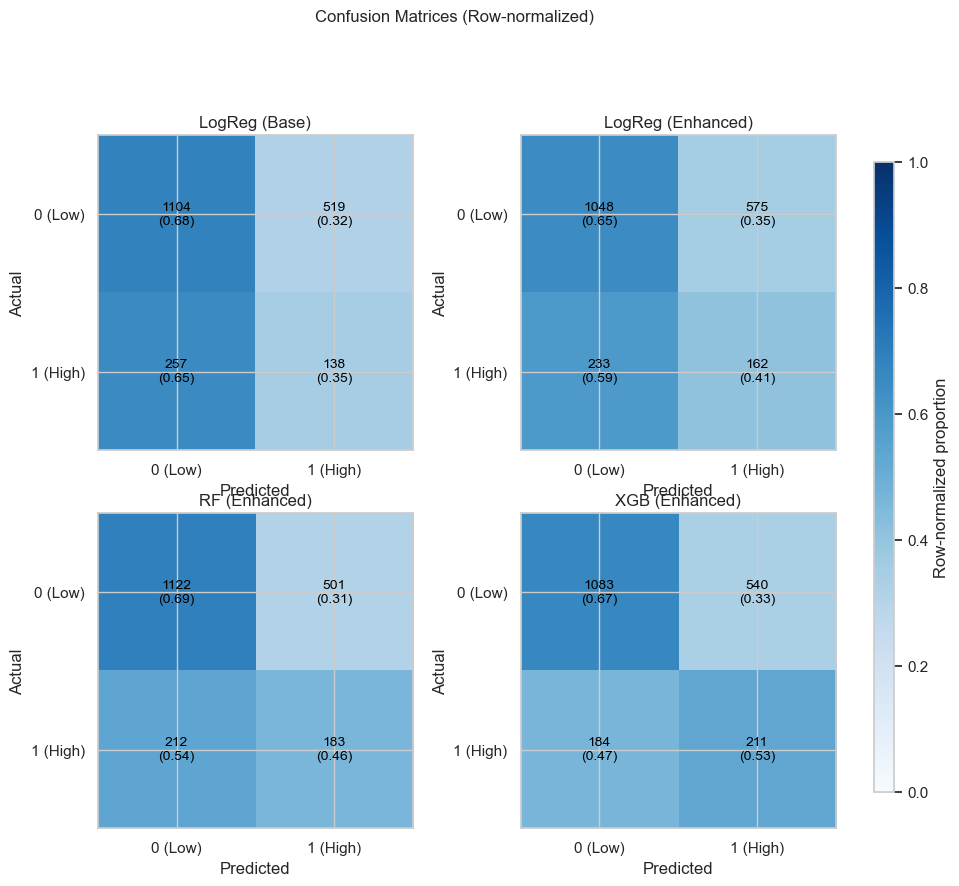

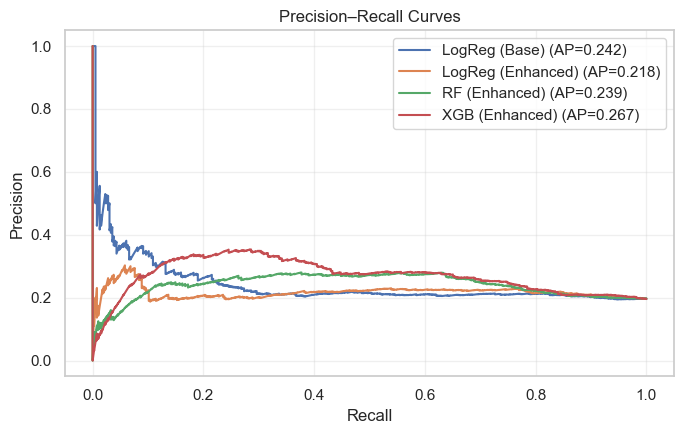

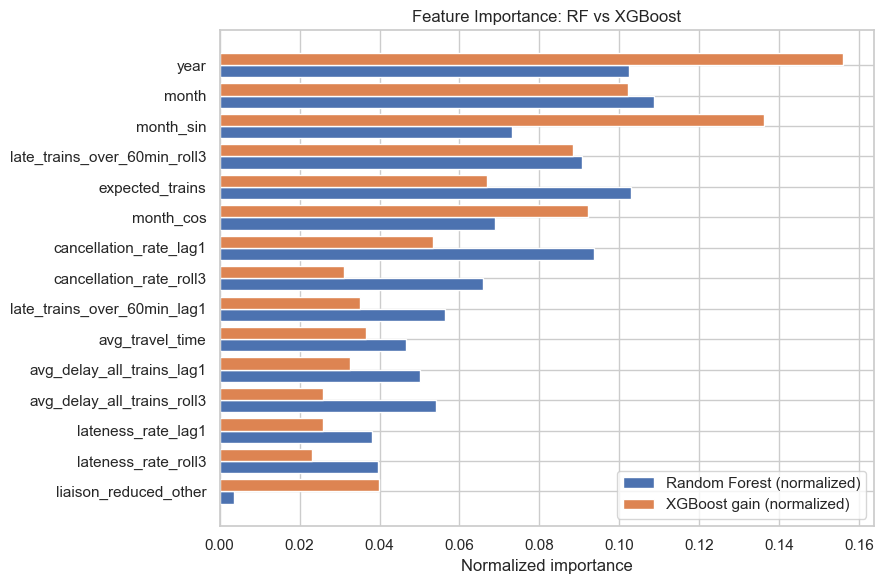

,rf,xgb_gain
liaison_reduced_other,0.003577,0.039848
lateness_rate_roll3,0.039735,0.023137
lateness_rate_lag1,0.038034,0.025819
avg_delay_all_trains_roll3,0.054236,0.025868
avg_delay_all_trains_lag1,0.050237,0.032662
avg_travel_time,0.046680,0.036711
late_trains_over_60min_lag1,0.056275,0.035012
cancellation_rate_roll3,0.065846,0.031111
cancellation_rate_lag1,0.093692,0.053274
month_cos,0.068843,0.092213


In [59]:
# ============================================================
# 0) Model registry: 
# ============================================================
models = {
    "LogReg (Base)": {
        "recall": recall_lr1, "f1": f1_lr1, "pr_auc": pr_auc_lr1,
        "cm": cm_lr1,
        "y_proba": y_proba1,
        "estimator": best_lr1 if "best_lr1" in globals() else None,
    },
    "LogReg (Enhanced)": {
        "recall": recall_lr2, "f1": f1_lr2, "pr_auc": pr_auc_lr2,
        "cm": cm_lr2,
        "y_proba": y_proba2,
        "estimator": best_lr2 if "best_lr2" in globals() else None,
    },
    "RF (Enhanced)": {
        "recall": recall_rf, "f1": f1_rf, "pr_auc": pr_auc_rf,
        "cm": cm_rf,
        "y_proba": y_proba3,
        "estimator": best_rf if "best_rf" in globals() else None,
    },
    "XGB (Enhanced)": {
        "recall": recall_xgb, "f1": f1_xgb, "pr_auc": pr_auc_xgb,
        "cm": cm_xgb,
        "y_proba": y_proba4,
        "estimator": best_xgb if "best_xgb" in globals() else None,
    },
}

# Enforce a specific display order
model_order = ["LogReg (Base)", "LogReg (Enhanced)", "RF (Enhanced)", "XGB (Enhanced)"]
models = {k: models[k] for k in model_order if k in models}

# ============================================================
# 1) Results table
# ============================================================
def build_results_table(models_dict: dict) -> pd.DataFrame:
    rows = []
    for name, d in models_dict.items():
        rows.append({
            "model": name,
            "recall": d.get("recall", np.nan),
            "f1": d.get("f1", np.nan),
            "pr_auc": d.get("pr_auc", np.nan),
        })
    df_res = pd.DataFrame(rows)
    
    # sort by primary metric (recall) then F1, then PR-AUC
    df_res = df_res.sort_values(["recall", "f1", "pr_auc"], ascending=False).reset_index(drop=True)
    return df_res

results = build_results_table(models)

# ============================================================
# 2) Chart A — Metric comparison (grouped bars)
# ============================================================
def plot_metric_comparison(results_df: pd.DataFrame, title="Model Comparison on Key Metrics (Test Set)"):
    results_df = results_df.copy()
    x = np.arange(len(results_df))
    width = 0.25

    plt.figure(figsize=(10, 4))
    plt.bar(x - width, results_df["recall"], width, label="Recall")
    plt.bar(x,         results_df["f1"],     width, label="F1")
    plt.bar(x + width, results_df["pr_auc"], width, label="PR-AUC")

    plt.xticks(x, results_df["model"], rotation=20, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ============================================================
# 3) Chart B — Confusion matrices (ALL in one figure, row-normalized)
# ============================================================
def _normalize_cm_rows(cm: np.ndarray) -> np.ndarray:
    denom = cm.sum(axis=1, keepdims=True).astype(float)
    denom[denom == 0] = 1.0
    return cm / denom

def plot_confusion_matrices_grid(models_dict: dict, ncols=2):
    cms = [(name, d["cm"]) for name, d in models_dict.items() if d.get("cm") is not None]
    if not cms:
        print("No confusion matrices found.")
        return

    n = len(cms)
    nrows = int(np.ceil(n / ncols))

    # Create figure and grid
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    im = None
    for ax_i, (name, cm) in enumerate(cms):
        ax = axes[ax_i]
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
        ax.set_title(name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_xticks([0, 1], labels=["0 (Low)", "1 (High)"])
        ax.set_yticks([0, 1], labels=["0 (Low)", "1 (High)"])

        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]:.2f})",
                        ha="center", va="center", color="black", fontsize=10)

    # Turn off unused axes
    for k in range(len(cms), len(axes)):
        axes[k].axis("off")

    # 🔥 Add a dedicated axis for the colorbar (no overlap)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("Row-normalized proportion")

    fig.suptitle("Confusion Matrices (Row-normalized)", y=1.02, fontsize=12)
    plt.show()


# ============================================================
# 4) Chart C — Precision–Recall curves (one plot)
# ============================================================
def plot_pr_curves(models_dict: dict, y_true, title="Precision–Recall Curves"):
    plt.figure(figsize=(7, 4.5))

    plotted_any = False
    for name, d in models_dict.items():
        y_proba = d.get("y_proba", None)
        if y_proba is None:
            continue
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        ap = average_precision_score(y_true, y_proba)
        plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")
        plotted_any = True

    if not plotted_any:
        print("No probability scores found for PR curves.")
        return

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ============================================================
# 5) Chart D — Feature importance: RF vs XGB (robust version)
# ============================================================
def get_rf_importance(best_rf, feature_names):
    if best_rf is None:
        return None
    imp = pd.Series(best_rf.feature_importances_, index=feature_names, name="rf")
    s = imp.sum()
    return imp / (s + 1e-12)

def get_xgb_importance_gain(best_xgb, feature_names):
    if best_xgb is None:
        return None
    booster = best_xgb.get_booster()
    gain_dict = booster.get_score(importance_type="gain")  # keys like 'f0', 'f1' if trained on numpy

    # If keys are 'f0'...'fN', map them back to feature_names
    if len(gain_dict) > 0 and next(iter(gain_dict.keys())).startswith("f"):
        mapped = {}
        for k, v in gain_dict.items():
            try:
                idx = int(k[1:])
                if 0 <= idx < len(feature_names):
                    mapped[feature_names[idx]] = v
            except:
                pass
        xgb_imp = pd.Series(mapped, name="xgb_gain")
    else:
        # assume keys are actual feature names
        xgb_imp = pd.Series(gain_dict, name="xgb_gain")

    xgb_imp = xgb_imp.reindex(feature_names).fillna(0.0)
    s = xgb_imp.sum()
    return xgb_imp / (s + 1e-12)

def plot_rf_vs_xgb_importance(best_rf, best_xgb, feature_names, top_n=15, title="Feature Importance: RF vs XGBoost"):
    rf_imp = get_rf_importance(best_rf, feature_names)
    xgb_imp = get_xgb_importance_gain(best_xgb, feature_names)

    if rf_imp is None and xgb_imp is None:
        print("No estimators available for feature importance.")
        return None

    if rf_imp is None:
        rf_imp = pd.Series(0.0, index=feature_names, name="rf")
    if xgb_imp is None:
        xgb_imp = pd.Series(0.0, index=feature_names, name="xgb_gain")

    comp = pd.concat([rf_imp, xgb_imp], axis=1).fillna(0)
    comp["combined"] = comp["rf"] + comp["xgb_gain"]

    top = comp.sort_values("combined", ascending=False).head(top_n).sort_values("combined", ascending=True)

    y = np.arange(len(top))
    h = 0.4
    plt.figure(figsize=(9, 6))
    plt.barh(y - h/2, top["rf"].values, height=h, label="Random Forest (normalized)")
    plt.barh(y + h/2, top["xgb_gain"].values, height=h, label="XGBoost gain (normalized)")
    plt.yticks(y, top.index)
    plt.xlabel("Normalized importance")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return top.drop(columns=["combined"])

# ============================================================
# 6) Run all summary outputs
# ============================================================
display(results.style.format({"recall":"{:.3f}", "f1":"{:.3f}", "pr_auc":"{:.3f}"}))

plot_metric_comparison(results)
plot_confusion_matrices_grid(models, ncols=2)
plot_pr_curves(models, y_test)

# Feature importance comparison (only makes sense for enhanced feature set)
imp_compare = plot_rf_vs_xgb_importance(
    models.get("RF (Enhanced)", {}).get("estimator"),
    models.get("XGB (Enhanced)", {}).get("estimator"),
    feature_names=hist_features,
    top_n=15
)
imp_compare


## D. Conclusion

#### _General Overview_

In this project, we developed an analytical framework to understand and forecast reliability risks in the French high-speed rail network. We defined a “high-risk” month as one characterized by elevated lateness and cancellation rates, extreme delay occurrences, and significant operational disruption. By crafting leakage-safe features—including lagged performance indicators and seasonality proxies—and training models using time-aware cross-validation with class-balanced learning, we demonstrated that historic performance momentum is a strong predictor of future risk. 

Various models were evaluated, starting with a baseline logistic regression model, which was then enhanced with lag features, with these features then progressively applied to Random Forest and XGBoost. 

Among the models evaluated, XGBoost demonstrated the best performance. Recall of upcoming high-risk episodes increased progressively with each model, but XGBoost was the best at balancing both recall and precision, which was important for the operational context to be able to catch as many high risk routes as possible, while maintaining operational bandwidth. 

The model coefficients and feature importances highlighted interpretable drivers—such as rising lateness rates and cancellation momentum—that align with operational intuition. XGBoost also demonstrated better ability to identify longer term trends beyond recent incidents. 



#### _Key Takeaways_

* High-risk months are rare but predictable: Extreme delays and cancellations tend to follow recent performance deterioration (momentum effects), rather than occurring at random.
* History matters more than structure: Lagged lateness and cancellation rates are stronger predictors of future risk than static route characteristics alone.
* Seasonality amplifies vulnerability: Certain months systematically show elevated risk, reinforcing the need for seasonal readiness planning.


#### _Operational Implications_

* Early warning is feasible: Routes showing sustained increases in lateness or cancellations over recent months should be flagged as near-term risk candidates. Consequently, Operator should proactively track important recent indicators to help identify potential trends. 
* Focus on tail risk, not averages: Targeting the drivers of extreme delays yields greater reliability gains than optimizing for mean performance.

#### _Recommended Actions_

* Preventive maintenance: Prioritize inspections and asset checks on routes with rising delay/cancellation momentum.
* Operational readiness: Allocate standby rolling stock, crew, and recovery resources to routes flagged as high-risk for the coming month.
* Seasonal playbooks: Implement month-specific readiness measures during historically high-risk periods.

#### _Possible Next Steps_

* Integrate more trending data: We did not go into details on incident causes within the analysis as these were leakage features. However trending of past incident causes may be useful to highlight potential increases and therefore early interventions required e.g. infra defects not tended to can deteriorate further with time. 
* Cost-weighted decisioning: Combine predicted risk with train volumes or passenger exposure to prioritize interventions by impact. Using this to finetune the target feature y in identifying "high risk" routes. 
* Threshold optimization: Calibrate decision thresholds to balance recall (catching risk) against operational capacity for false alarms.
* Granular modeling: Extend from route-month to finer levels (e.g., station segments or fleet groups) where data allows.
* Continuous monitoring: Deploy the model in a rolling forecast framework to update risk rankings monthly and track intervention outcomes. Model would learn and improve as data points become more targeted and precise. 